# Ames Housing Price Prediction

In this project, I will build a **machine learning regression model to predict house sale prices** using the Ames Housing dataset. The project involves **supervised learning for regression**, where the **target variable is "SalePrice"**, representing the final sale price of each property.

I will use the following **pipeline based on the CRISP-DM framework**:

1. Define the business problem.
2. Collect the data and get a general overview of it.
3. Split the data into train and test sets.
4. Explore the data through exploratory data analysis.
5. Perform feature engineering, data cleaning and preprocessing.
6. Train, compare and tune machine learning models.
7. Evaluate the final production model.
8. Conclude and interpret the model results.

In this notebook, I will perform **exploratory data analysis (EDA)**, covering steps **1 to 4** of the pipeline above. The main objective is to understand the structure of the dataset, investigate the relationship between property characteristics and sale price, identify missing values and outliers, and generate insights that will guide the preprocessing and modeling stages.

## 1. Business problem

- A real estate company, investor or homeowner wants to estimate the fair market value of a residential property based on its characteristics.

- Incorrect pricing can lead to important business problems:
  - Overpricing may reduce buyer interest and increase time on market.
  - Underpricing may lead to financial losses for sellers.
  - Poor price estimation can affect investment decisions and negotiation strategies.

- The objective of this project is to build a regression model capable of predicting house sale prices using property-related variables such as area, overall quality, neighborhood, garage size, basement features, year built and other housing attributes.

- This type of model can support:
  - More accurate property valuation.
  - Better pricing decisions.
  - Identification of the main factors that influence house prices.
  - Data-driven insights for real estate decision-making.

### Importing the libraries

In [71]:
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Local 
sys.path.append("../src")
from eda_utils import (analyze_categorical_feature,calculate_iqr_outliers)

# Settings
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)

### Visualization settings

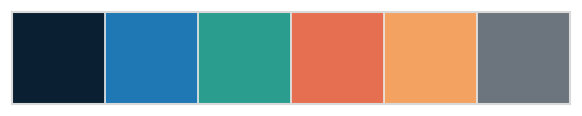

In [72]:
%matplotlib inline

project_palette = [
    "#0B1F33",  # Dark navy
    "#1F77B4",  # Blue
    "#2A9D8F",  # Teal
    "#E76F51",  # Terracotta
    "#F4A261",  # Soft orange
    "#6C757D"   # Neutral gray
]

main_color = "#0B1F33"
secondary_color = "#1F77B4"
positive_color = "#2A9D8F"
highlight_color = "#E76F51"
accent_color = "#F4A261"
neutral_color = "#6C757D"

sns.set_theme(style="whitegrid",palette=project_palette,font_scale=1.05)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.edgecolor"] = "#D9D9D9"
plt.rcParams["axes.labelcolor"] = "#0B1F33"
plt.rcParams["xtick.color"] = "#0B1F33"
plt.rcParams["ytick.color"] = "#0B1F33"
plt.rcParams["grid.color"] = "#EAEAEA"
plt.rcParams["grid.linestyle"] = "-"
plt.rcParams["axes.titleweight"] = "bold"

sns.palplot(project_palette)
plt.show()

## 2. Dataset Overview

In this section, I will load the Ames Housing dataset and perform an initial inspection of its structure.

The goal is to understand the number of observations, number of features, data types, duplicated rows, missing values in the target variable and the general composition of numerical and categorical variables.

In [73]:
df = pd.read_csv('../input/AmesHousing.csv')
df = df.replace([np.inf, -np.inf], np.nan)

In [74]:
df.head(10)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
5,6,527105030,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal,195500
6,7,527127150,120,RL,41.0,4920,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,2001,2001,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,616.0,Unf,0.0,722.0,1338.0,GasA,Ex,Y,SBrkr,1338,0,0,1338,1.0,0.0,2,0,2,1,Gd,6,Typ,0,NaN,Attchd,2001.0,Fin,2.0,582.0,TA,TA,Y,0,0,170,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,213500
7,8,527145080,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal,191500
8,9,527146030,120,RL,39.0,5389,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1995,1996,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Gd,TA,PConc,Gd,TA,No,GLQ,1180.0,Unf,0.0,415.0,1595.0,GasA,Ex,Y,SBrkr,1616,0,0,1616,1.

### Data Dictionary Overview

The Ames Housing dataset contains 82 variables that describe different characteristics of residential properties sold in Ames, Iowa. Since the dataset has many columns, listing every variable in the notebook would make this section too long. For this reason, the variables are grouped into broader categories to make the first overview easier to understand.

1. **Identifier variables:** Columns used to identify each observation or property, such as Order and PID.

2. **Target variable:** SalePrice, which represents the final sale price of each house and is the variable that the model will try to predict.

3. **Location and zoning features:** Variables that describe where the property is located and how it is classified, such as MS Zoning, Neighborhood, Condition 1 and Condition 2.

4. **Lot and land features:** Variables related to the land itself, including lot size, street access, lot shape and land characteristics. Examples include Lot Area, Lot Frontage, Lot Shape, Street, Alley and Land Contour.

5. **Quality and condition features:** Variables that describe the general quality, condition and finishing of the property, such as Overall Qual, Overall Cond, Exter Qual, Kitchen Qual and Heating QC.

6. **Construction and remodeling features:** Variables related to the age, construction style and remodeling history of the house, such as Year Built, Year Remod/Add, Roof Style, Foundation and exterior materials.

7. **Basement features:** Variables that describe the basement structure, quality, exposure, finished area and bathrooms. Examples include Bsmt Qual, Bsmt Exposure, BsmtFin SF 1, Total Bsmt SF and Bsmt Full Bath.

8. **Living area and room features:** Variables related to the internal size and layout of the house, such as Gr Liv Area, 1st Flr SF, 2nd Flr SF, Full Bath, Bedroom AbvGr and TotRms AbvGrd.

9. **Garage features:** Variables that describe the garage type, size, capacity, quality and condition, such as Garage Type, Garage Cars, Garage Area, Garage Qual and Garage Cond.

10. **Outdoor and additional features:** Variables related to outdoor areas and extra property characteristics, such as Wood Deck SF, Open Porch SF, Pool Area, Fence and Misc Feature.

11. **Sale information:** Variables that describe when and how the property was sold, such as Mo Sold, Yr Sold, Sale Type and Sale Condition.

In [75]:
print(f'Dataset Rows: {df.shape[0]}')
print(f'Dataset Columns: {df.shape[1]}')

Dataset Rows: 2930
Dataset Columns: 82


In [76]:
print(f'Dataset Duplicated Rows: {df.duplicated().sum()}')
print(f'Dataset Missing Values in SalePrice: {df["SalePrice"].isna().sum()}')

Dataset Duplicated Rows: 0
Dataset Missing Values in SalePrice: 0


In [77]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print(f'Numerical features: {len(numerical_features)}')
print(f'Categorical features: {len(categorical_features)}')


Numerical features: 39
Categorical features: 43


In [78]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Order,2930.0,1.465500e+03,8.459625e+02,1.0,7.332500e+02,1465.5,2.197750e+03,2.930000e+03
PID,2930.0,7.144645e+08,1.887308e+08,526301100.0,5.284770e+08,535453620.0,9.071811e+08,1.007100e+09
MS SubClass,2930.0,5.738737e+01,4.263802e+01,20.0,2.000000e+01,50.0,7.000000e+01,1.900000e+02
Lot Frontage,2440.0,6.922459e+01,2.336533e+01,21.0,5.800000e+01,68.0,8.000000e+01,3.130000e+02
Lot Area,2930.0,1.014792e+04,7.880018e+03,1300.0,7.440250e+03,9436.5,1.155525e+04,2.152450e+05
Overall Qual,2930.0,6.094881e+00,1.411026e+00,1.0,5.000000e+00,6.0,7.000000e+00,1.000000e+01
Overall Cond,2930.0,5.563140e+00,1.111537e+00,1.0,5.000000e+00,5.0,6.000000e+00,9.000000e+00
Year Built,2930.0,1.971356e+03,3.024536e+01,1872.0,1.954000e+03,1973.0,2.001000e+03,2.010000e+03
Year Remod/Add,2930.0,1.984267e+03,2.086029e+01,1950.0,1.965000e+03,1993.0,2.004000e+03,2.010000e+03
Mas Vnr Area,2907.0,1.018968e+02,1.791126e+02,0.0,0.000000e+00,0.0,1.640000e+02,1.600000e+03


Some insights:

1. The dataset contains 2,930 observations, according to the count of most numerical variables.

2. Some numerical variables have lower counts than 2,930, which suggests that not all columns are fully populated. This will need to be investigated later in the missing values analysis.

3. SalePrice has a mean of approximately 180,796 and a median of 160,000. Since the mean is higher than the median, the target variable appears to be right-skewed.

4. The maximum SalePrice is 755,000, while the third quartile is 213,500. This indicates that a small number of houses are sold at much higher prices than most properties in the dataset.

5. Lot Area also shows a large difference between its third quartile and maximum value. Most houses have lot areas below around 11,555 square feet, but the maximum value is much higher, suggesting the presence of unusually large lots.

6. Overall Qual has a median value of 6, meaning that most houses are concentrated around average to above-average overall quality.

7. Year Built ranges from 1872 to 2010, showing that the dataset includes both very old and recently built houses.

8. Year Remod/Add also ranges up to 2010, indicating that some properties were recently remodeled or updated.

9. Gr Liv Area has a mean close to 1,500 square feet, but its maximum value is much higher than the third quartile, suggesting that some houses have substantially larger living areas.

10. Several area-related variables have minimum values equal to zero, such as Mas Vnr Area, BsmtFin SF 1, BsmtFin SF 2, Wood Deck SF, Open Porch SF and Pool Area. This suggests that many houses do not have some of these specific features.

11. Garage Cars has a median value of 2, indicating that a typical property in the dataset has garage capacity for two cars.

12. The sale years range from 2006 to 2010, meaning that the dataset covers house sales over a limited five-year period.

## 3. Train-Test Split

Before performing the full exploratory data analysis, I will split the dataset into training and test sets.

I will use the training set to explore the data, identify patterns, understand preprocessing needs and guide feature engineering decisions. The test set will be kept untouched until the final model evaluation.

This approach helps prevent data leakage and allows the final model performance to be evaluated on unseen data.

In [79]:
target = 'SalePrice'            
X = df.drop(columns=[target])   
y = df[target]                  

print(f'X shape: {X.shape}')    
print(f'y shape: {y.shape}')

X shape: (2930, 81)
y shape: (2930,)


In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X,                                       
    y,                                         
    test_size=0.2,                       
    random_state=42                                    
)

print(f'X_train shape: {X_train.shape}')                
print(f'X_test shape: {X_test.shape}')                  
print(f'y_train shape: {y_train.shape}')                
print(f'y_test shape: {y_test.shape}')                  

X_train shape: (2344, 81)
X_test shape: (586, 81)
y_train shape: (2344,)
y_test shape: (586,)


In [81]:
train_data = X_train.copy()                         
train_data[target] = y_train                        

test_data = X_test.copy()                           
test_data[target] = y_test                          

print(f'Train data shape: {train_data.shape}')
print(f'Test data shape: {test_data.shape}')

Train data shape: (2344, 82)
Test data shape: (586, 82)


In [82]:
total_rows = df.shape[0]                            
train_ratio = train_data.shape[0]/total_rows        
test_ratio = test_data.shape[0]/total_rows          

print(f'Train ratio: {train_ratio:.2%}')
print(f'Test ratio: {test_ratio:.2%}')

Train ratio: 80.00%
Test ratio: 20.00%


### Train-Test Split Summary

I split the dataset using an 80/20 proportion:

- Training set: 2,344 rows and 82 columns
- Test set: 586 rows and 82 columns

From now on, I will use only the training set during the exploratory data analysis. This allows me to investigate patterns, missing values, outliers and feature relationships without exposing the test data too early.

The test set will remain untouched and will only be used at the end of the project to evaluate how well the final model generalizes to unseen data.

## 4. Target Variable Analysis

In this section, I will analyze the target variable SalePrice.

The goal is to understand how house prices are distributed, check whether the target variable is skewed, identify potential outliers and evaluate whether a log transformation could be useful for the modeling stage.

And again, all analyses in this section will be performed only on the training data to avoid data leakage.

In [83]:
train_data['SalePrice'].describe()

count      2344.000000
mean     178582.207765
std       77125.072713
min       12789.000000
25%      129000.000000
50%      160000.000000
75%      210000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [84]:
mean_price = train_data['SalePrice'].mean()
median_price = train_data['SalePrice'].median()
skewness_price = train_data['SalePrice'].skew()

print(f'Mean SalePrice: ${mean_price:,.2f}')
print(f'Median SalePrice: ${median_price:,.2f}')
print(f'SalePrice Skewness: {skewness_price:.2f}')

Mean SalePrice: $178,582.21
Median SalePrice: $160,000.00
SalePrice Skewness: 1.75


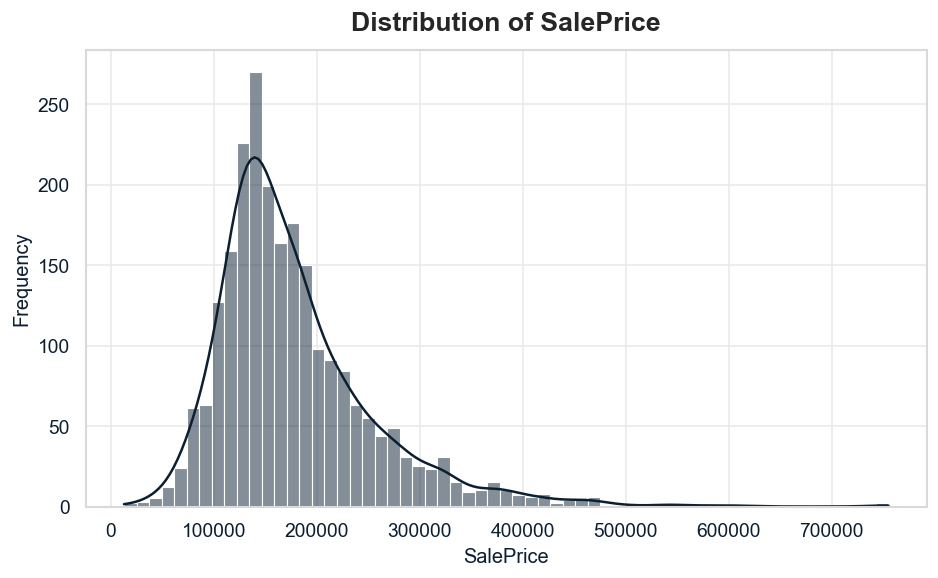

In [85]:
plt.figure(figsize=(8, 5), dpi=120)
sns.histplot(train_data["SalePrice"],kde=True)
plt.title("Distribution of SalePrice",fontsize=16,fontweight="bold",pad=12)
plt.xlabel("SalePrice", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()
plt.show()

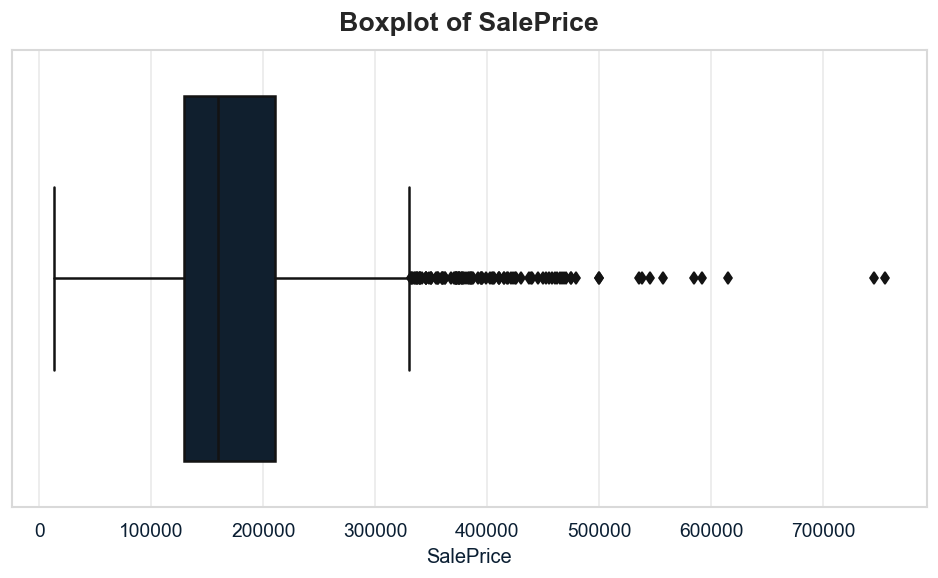

In [86]:
plt.figure(figsize=(8, 5), dpi=120)
sns.boxplot(x=train_data["SalePrice"])
plt.title(
    "Boxplot of SalePrice",
    fontsize=16,
    fontweight="bold",
    pad=12
)
plt.xlabel("SalePrice", fontsize=12)
plt.tight_layout()
plt.show()

In [87]:
q1 = train_data['SalePrice'].quantile(0.25)
q3 = train_data['SalePrice'].quantile(0.75)
iqr = q3 - q1

lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

lower_outliers = train_data[train_data['SalePrice'] < lower_limit]
upper_outliers = train_data[train_data['SalePrice'] > upper_limit]

print(f'Lower limit: ${lower_limit:,.2f}')
print(f'Upper limit: ${upper_limit:,.2f}')
print(f'Lower outliers: {lower_outliers.shape[0]}')
print(f'Upper outliers: {upper_outliers.shape[0]}')

Lower limit: $7,500.00
Upper limit: $331,500.00
Lower outliers: 0
Upper outliers: 107


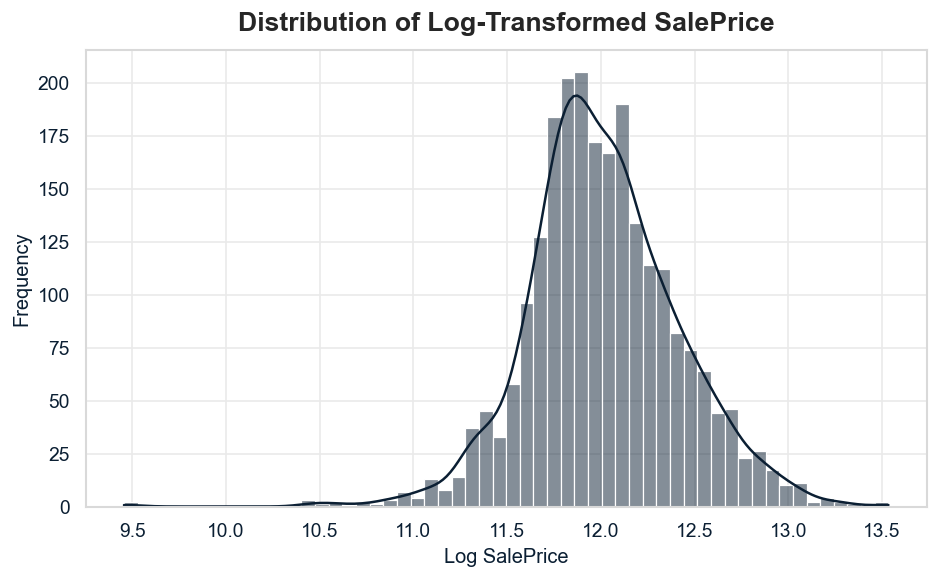

In [88]:
log_saleprice = np.log1p(train_data['SalePrice'])

plt.figure(figsize=(8,5), dpi=120)
sns.histplot(log_saleprice, kde=True)
plt.title('Distribution of Log-Transformed SalePrice',fontsize=16,fontweight="bold",pad=12)
plt.xlabel('Log SalePrice', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

In [89]:
original_skewness = train_data['SalePrice'].skew()
log_skewness = log_saleprice.skew()
print(f'Original SalePrice Skewness: {original_skewness:.2f}')
print(f'Log-Transformed SalePrice Skewness: {log_skewness:.2f}')

Original SalePrice Skewness: 1.75
Log-Transformed SalePrice Skewness: -0.09


### Target Variable Insights

The target variable SalePrice is clearly right-skewed. Most houses are concentrated in the lower and mid-price ranges, while only a smaller group of properties reaches very high sale prices.

This also explains why the mean sale price is higher than the median. A few expensive houses pull the average upward, which is a common behavior in real estate data.

The IQR method identified some potential upper outliers. However, I will not treat these observations as errors automatically, because expensive houses can be valid and meaningful examples in this type of dataset.

After applying a log transformation to SalePrice, the distribution became much more balanced and symmetric. Because of that, using the log-transformed target may be a good strategy during the modeling stage, especially for models that are more sensitive to skewed distributions.

## 5. Numerical Features Analysis

In this section, I will analyze the numerical features in the training data.

The main goal is to identify which numerical variables have the strongest relationship with SalePrice and understand how these variables may influence house prices.

This analysis will help guide future decisions related to feature selection, feature engineering and model building.

In [90]:
numeric_features = train_data.select_dtypes(include=["int64", "float64"])
numeric_features = numeric_features.drop(columns=["Order", "PID", "MS SubClass"],errors="ignore")

print(f"Number of numerical features: {numeric_features.shape[1]}")
numeric_features.columns

Number of numerical features: 36


Index(['Lot Frontage', 'Lot Area', 'Overall Qual', 'Overall Cond',
       'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'BsmtFin SF 1',
       'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt',
       'Garage Cars', 'Garage Area', 'Wood Deck SF', 'Open Porch SF',
       'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val',
       'Mo Sold', 'Yr Sold', 'SalePrice'],
      dtype='object')

Some columns are stored as numerical values but should not be interpreted as continuous numerical features. For example, Order and PID are identifiers, while MS SubClass represents dwelling categories. For this reason, these variables were removed from the numerical correlation analysis.

In [91]:
correlation_with_target = numeric_features.corr()['SalePrice'].sort_values(ascending=False)
correlation_with_target.head(15)

SalePrice         1.000000
Overall Qual      0.795298
Gr Liv Area       0.698315
Garage Cars       0.644304
Garage Area       0.633106
Total Bsmt SF     0.612256
1st Flr SF        0.607433
Year Built        0.545409
Full Bath         0.542053
Year Remod/Add    0.517653
Garage Yr Blt     0.516211
Mas Vnr Area      0.490912
TotRms AbvGrd     0.475455
Fireplaces        0.467501
BsmtFin SF 1      0.423906
Name: SalePrice, dtype: float64

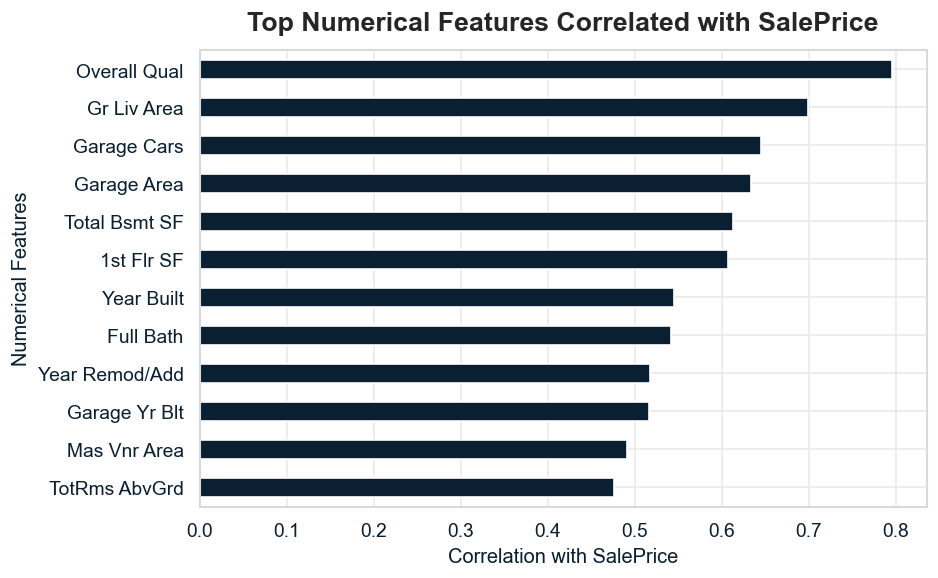

In [92]:
top_corr_features = correlation_with_target.drop("SalePrice").head(12)
plt.figure(figsize=(8, 5), dpi=120)
top_corr_features.sort_values().plot(kind="barh")
plt.title(
    "Top Numerical Features Correlated with SalePrice",
    fontsize=16,
    fontweight="bold",
    pad=12
)
plt.xlabel("Correlation with SalePrice", fontsize=12)
plt.ylabel("Numerical Features", fontsize=12)
plt.tight_layout()
plt.show()

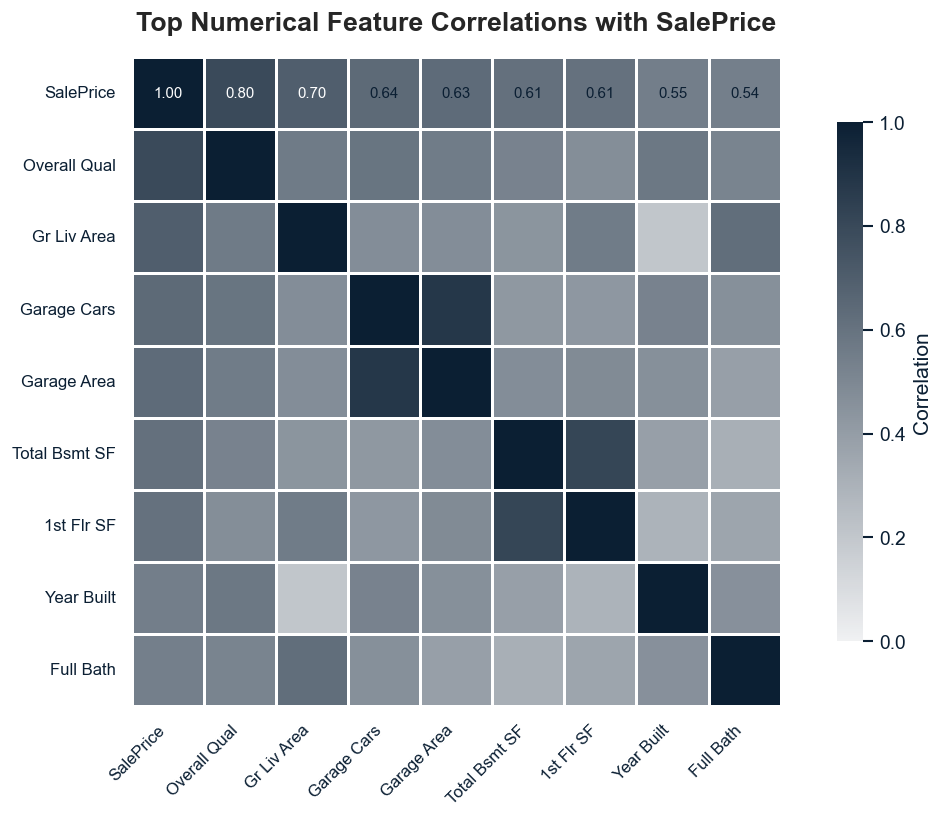

In [93]:
top_numeric_features = correlation_with_target.drop("SalePrice").head(8).index.tolist()
heatmap_features = ["SalePrice"] + top_numeric_features
top_corr_matrix = train_data[heatmap_features].corr()

plt.figure(figsize=(10, 7), dpi=120)
heatmap_cmap = sns.light_palette("#0B1F33", as_cmap=True)
ax = sns.heatmap(
    top_corr_matrix,
    annot=True,
    fmt=".2f",
    cmap=heatmap_cmap,
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.7,
    linecolor="white",
    cbar_kws={
        "shrink": 0.8,
        "label": "Correlation"
    }
)

for text in ax.texts:
    value = float(text.get_text())
    text.set_fontsize(9)
    text.set_color("white" if value >= 0.65 else "#0B1F33")

plt.title(
    "Top Numerical Feature Correlations with SalePrice",
    fontsize=16,
    fontweight="bold",
    pad=16
)

plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

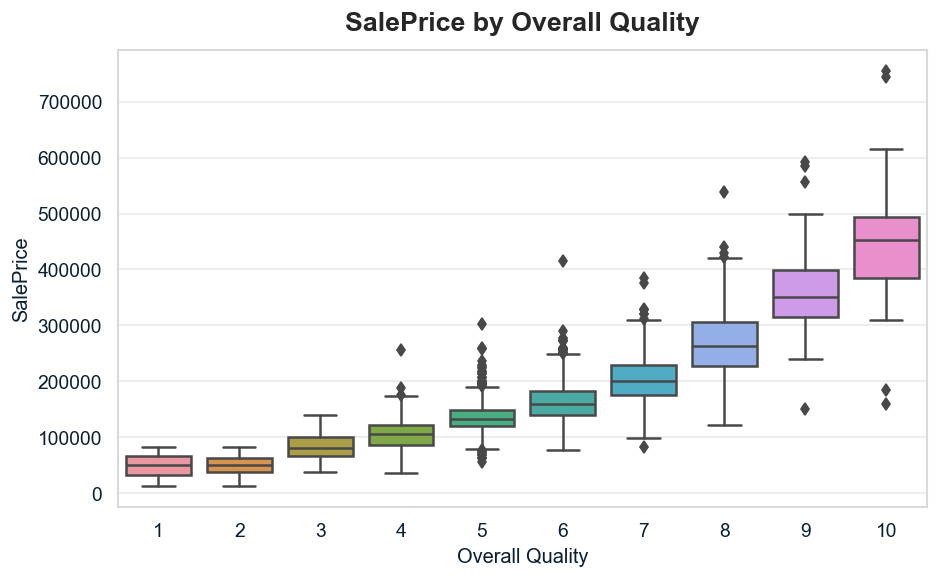

In [94]:
plt.figure(figsize=(8, 5), dpi=120)
sns.boxplot(data=train_data, x="Overall Qual", y="SalePrice")
plt.title("SalePrice by Overall Quality", fontsize=16, fontweight="bold", pad=12)
plt.xlabel("Overall Quality", fontsize=12)
plt.ylabel("SalePrice", fontsize=12)
plt.tight_layout()
plt.show()

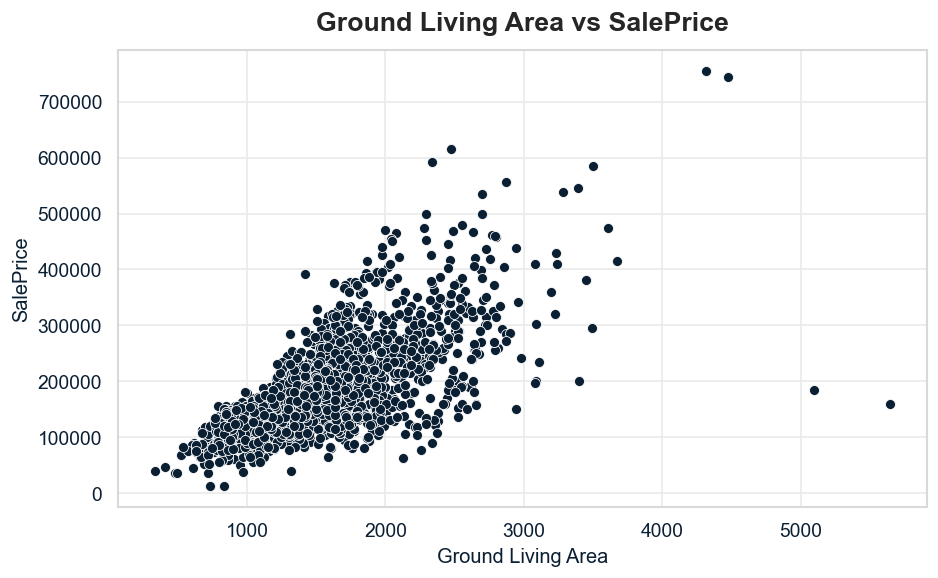

In [95]:
plt.figure(figsize=(8, 5), dpi=120)
sns.scatterplot(data=train_data, x="Gr Liv Area", y="SalePrice")
plt.title("Ground Living Area vs SalePrice", fontsize=16, fontweight="bold", pad=12)
plt.xlabel("Ground Living Area", fontsize=12)
plt.ylabel("SalePrice", fontsize=12)
plt.tight_layout()
plt.show()

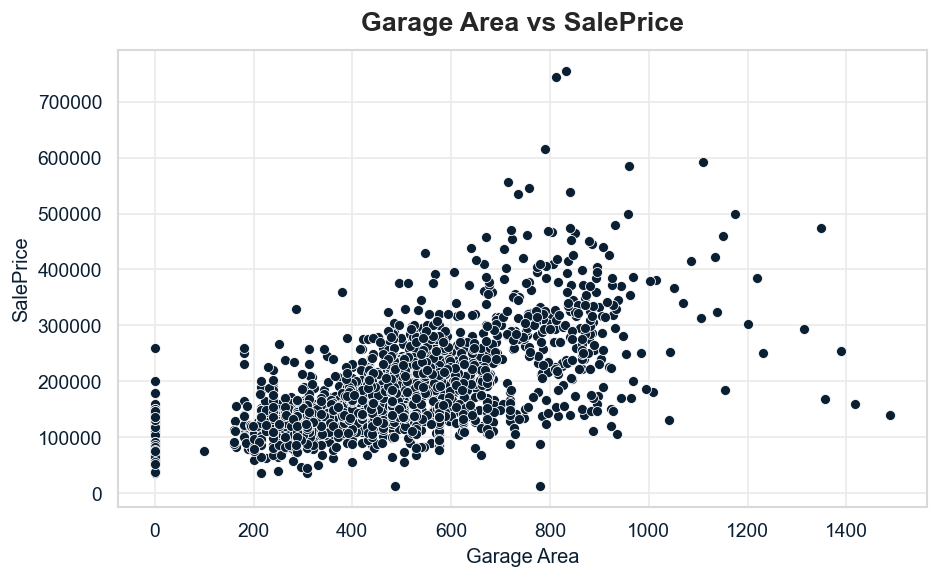

In [96]:
plt.figure(figsize=(8, 5), dpi=120)
sns.scatterplot(data=train_data, x="Garage Area", y="SalePrice")
plt.title("Garage Area vs SalePrice", fontsize=16, fontweight="bold", pad=12)
plt.xlabel("Garage Area", fontsize=12)
plt.ylabel("SalePrice", fontsize=12)
plt.tight_layout()
plt.show()

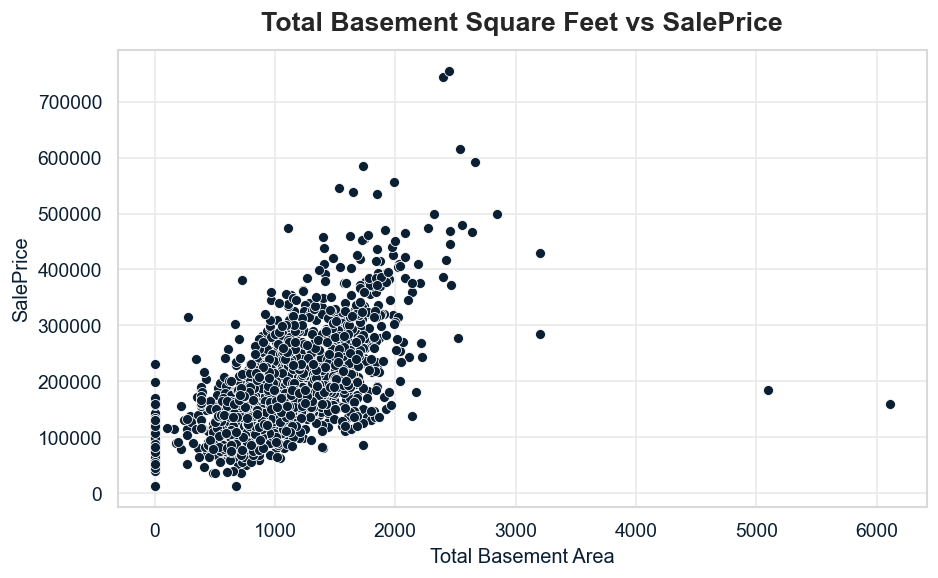

In [97]:
plt.figure(figsize=(8, 5), dpi=120)
sns.scatterplot(data = train_data, x = 'Total Bsmt SF', y = 'SalePrice')
plt.title('Total Basement Square Feet vs SalePrice', fontsize=16, fontweight="bold", pad=12)
plt.xlabel('Total Basement Area', fontsize=12)
plt.ylabel('SalePrice', fontsize=12)
plt.tight_layout()
plt.show()

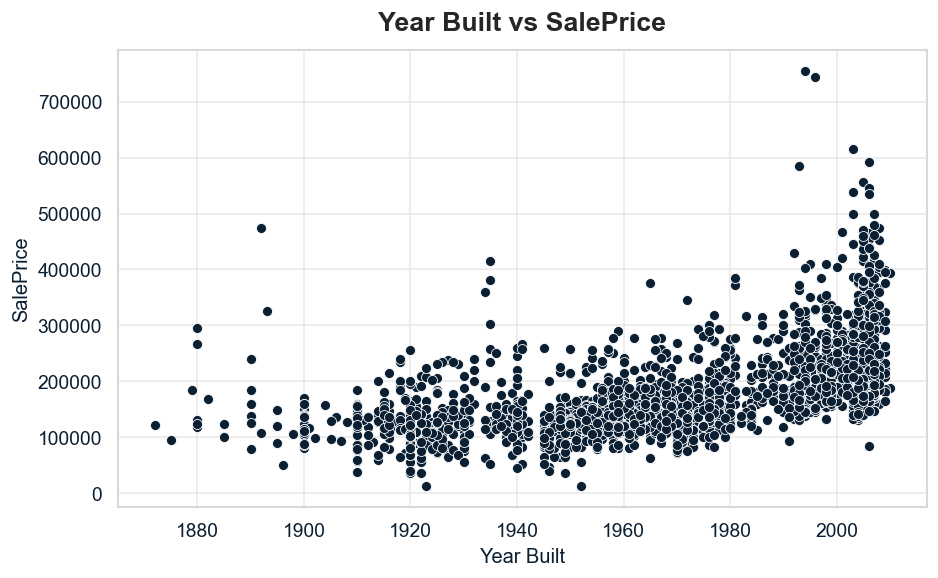

In [98]:
plt.figure(figsize=(8, 5), dpi=120)
sns.scatterplot(data = train_data, x = 'Year Built', y = 'SalePrice')
plt.title('Year Built vs SalePrice', fontsize=16, fontweight="bold", pad=12)
plt.xlabel('Year Built', fontsize=12)
plt.ylabel('SalePrice', fontsize=12)
plt.tight_layout()
plt.show()

In [99]:
# Compare SalePrice statistics by Overall Quality

overall_qual_summary = train_data.groupby('Overall Qual')['SalePrice'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

overall_qual_summary = overall_qual_summary.sort_index()
overall_qual_summary = overall_qual_summary.reset_index()
overall_qual_summary = overall_qual_summary.style.hide(axis='index').format({
    'count': '{:,.0f}',
    'mean': '{:,.2f}',
    'median': '{:,.2f}',
    'min': '{:,.2f}',
    'max': '{:,.2f}'
})

overall_qual_summary

Overall Qual,count,mean,median,min,max
1,4,"48,725.00","50,150.00","13,100.00","81,500.00"
2,10,"50,122.90","50,750.00","12,789.00","82,000.00"
3,30,"84,987.97","80,250.00","37,900.00","139,600.00"
4,177,"105,779.16","105,000.00","34,900.00","256,000.00"
5,675,"135,047.65","133,000.00","55,993.00","301,600.00"
6,613,"162,512.76","160,000.00","76,000.00","415,000.00"
7,465,"204,048.49","200,000.00","82,500.00","383,970.00"
8,267,"269,359.02","263,550.00","122,000.00","538,000.00"
9,81,"360,129.68","350,000.00","150,000.00","591,587.00"
10,22,"449,028.23","453,475.00","160,000.00","755,000.00"


### Numerical Features Insights

The correlation analysis shows that Overall Qual is the numerical feature most strongly related to SalePrice. This makes sense, since houses with better overall material and finish quality usually tend to have higher prices.

Gr Liv Area also has a strong positive relationship with SalePrice. In practical terms, this means that larger houses, especially in terms of above-ground living area, are generally associated with higher sale prices.

Garage-related variables, such as Garage Cars and Garage Area, also appear among the most relevant numerical features. This suggests that both garage capacity and garage size can add value to a property.

Other features related to property size and structure, such as Total Bsmt SF, 1st Flr SF, Full Bath and Year Built, also show positive relationships with SalePrice. This indicates that larger, newer and better-equipped houses tend to be more valuable.

Another important point is that some numerical features are strongly related to each other. For example, Garage Cars and Garage Area describe similar aspects of the property. I will keep this in mind during preprocessing and model selection, especially when using models that can be affected by multicollinearity.

## 6. Categorical Features Analysis

In this section, I analyze the categorical variables and their relationship with the target variable SalePrice.

Categorical features are important because they represent qualitative aspects of a property, such as neighborhood, house style, material quality, garage type, basement quality and sale condition.

The main goal is to understand which categories are associated with higher or lower sale prices and identify which categorical variables should be especially relevant during preprocessing and modeling.

In [100]:
categorical_features = train_data.select_dtypes(['object']).columns
print(f'Number of categorical features: {len(categorical_features)}')
categorical_features

Number of categorical features: 43


Index(['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour',
       'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
       'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature',
       'Sale Type', 'Sale Condition'],
      dtype='object')

The dataset contains 43 categorical features. These variables include location-related information, property quality indicators, garage characteristics, basement attributes and sale-related conditions.

Since machine learning models cannot use raw text categories directly, these features will need to be encoded during the preprocessing stage.

In [101]:
categorical_summary = pd.DataFrame({
    'Feature': categorical_features,
    'Unique Values': [train_data[col].nunique(dropna=False) for col in categorical_features],
    'Missing Values': [train_data[col].isna().sum() for col in categorical_features]
})

categorical_summary = categorical_summary.sort_values(by="Unique Values", ascending=False)
categorical_summary


,Feature,Unique Values,Missing Values
8,Neighborhood,28,0
16,Exterior 2nd,16,0
15,Exterior 1st,16,0
41,Sale Type,10,0
9,Condition 1,9,0
12,House Style,8,0
14,Roof Matl,8,0
31,Functional,8,0
10,Condition 2,8,0
24,BsmtFin Type 1,7,61


Neighborhood has the highest number of categories, which makes it an important variable to analyze separately. Other categorical features have fewer categories, but many of them represent quality levels that may have a strong relationship with house prices.

Some categorical variables also contain missing values. In this dataset, missing values often indicate that the house does not have a specific feature, such as no basement, no garage or no fireplace.

### 6.1 Neighborhood and SalePrice

Neighborhood is one of the most important categorical features in the dataset because location is usually a major driver of real estate prices.

To analyze this relationship, I compared the distribution and median sale price across neighborhoods.

In [102]:
neighborhood_summary = train_data.groupby('Neighborhood')['SalePrice'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

neighborhood_summary = neighborhood_summary.sort_values(by='median', ascending=False)

neighborhood_summary

,count,mean,median,min,max
Neighborhood,,,,,
NridgHt,121,312743.578512,316000.0,154000,615000
NoRidge,57,330866.807018,301500.0,190000,755000
StoneBr,36,326523.444444,298950.0,130000,591587
GrnHill,2,280000.000000,280000.0,230000,330000
Veenker,22,251115.909091,250250.0,150000,385000
Timber,59,240096.050847,228000.0,137500,425000
Somerst,136,226000.948529,220500.0,139000,468000
Greens,7,194321.428571,206000.0,155000,214000
CollgCr,211,200844.829384,200141.0,110000,475000


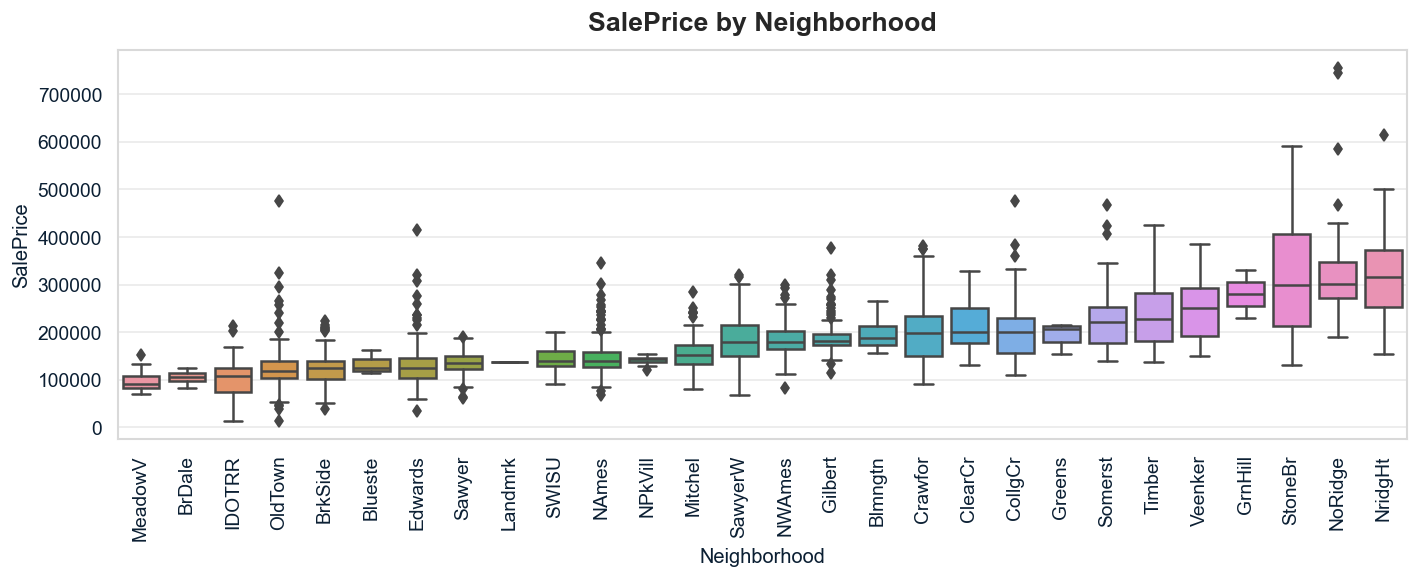

In [103]:
neighborhood_order = train_data.groupby('Neighborhood')['SalePrice'].median().sort_values().index

plt.figure(figsize=(12, 5))
sns.boxplot(data=train_data, x='Neighborhood', y='SalePrice', order=neighborhood_order)
plt.title('SalePrice by Neighborhood', fontsize=16, fontweight="bold", pad=12)
plt.xlabel('Neighborhood', fontsize=12)
plt.ylabel('SalePrice', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

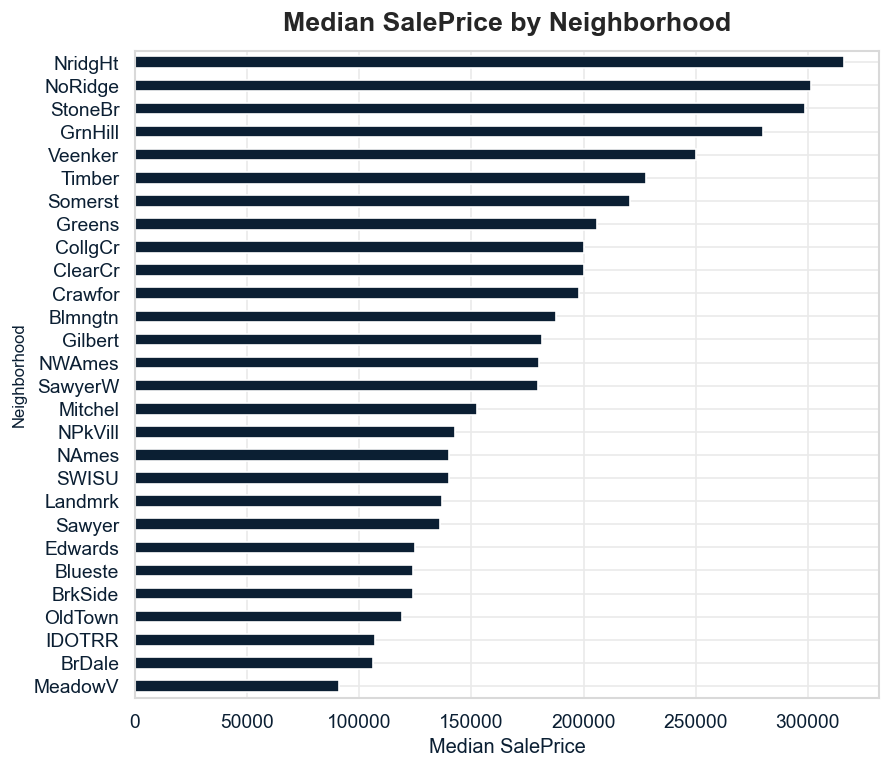

In [104]:
neighborhood_median_price = train_data.groupby('Neighborhood')['SalePrice'].median().sort_values()

plt.figure(figsize=(8,7))
neighborhood_median_price.plot(kind='barh')
plt.title('Median SalePrice by Neighborhood', fontsize=16, fontweight="bold", pad=12)
plt.xlabel('Median SalePrice', fontsize=12)
plt.ylabel('Neighborhood', fontsize=10)
plt.show()

Neighborhood shows clear differences in sale prices. Some neighborhoods have much higher median prices, while others are concentrated in lower price ranges.

This confirms that location is an important driver of house value and should be preserved during preprocessing.

### 6.2 Quality-Related Categorical Features

Several categorical variables describe the quality of different parts of the house. These features are especially important because they represent information that is not fully captured by size-related variables.

In this step, I analyzed features such as **Kitchen Qual**, **Exter Qual**, **Bsmt Qual** and **Fireplace Qu**.

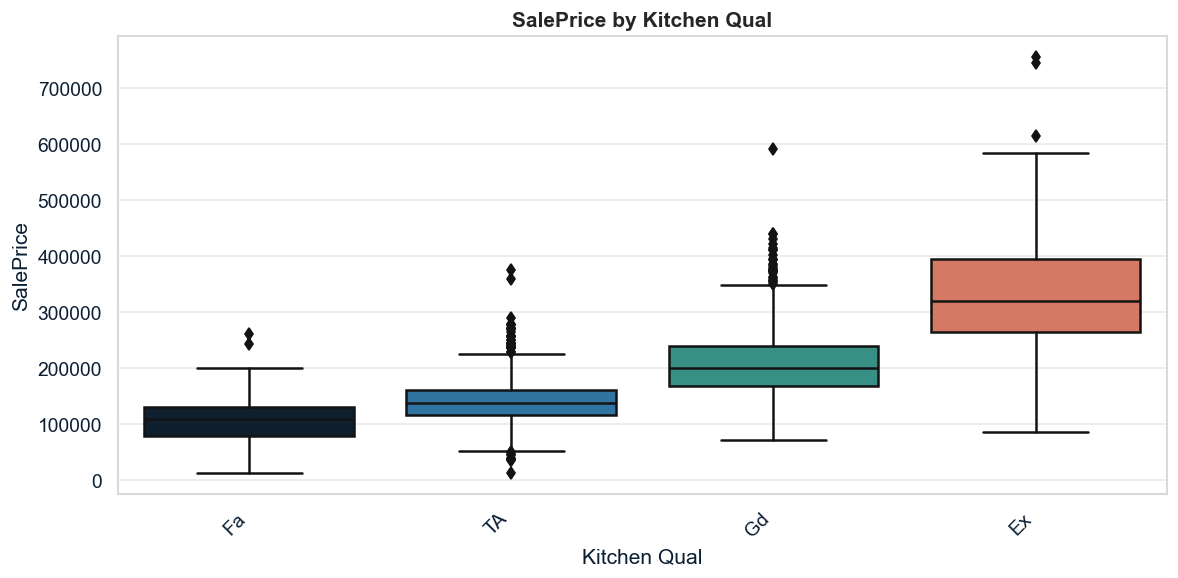

,count,mean,median,min,max
Kitchen Qual,,,,,
Ex,150,330569.146667,320000.0,86000,755000
Gd,911,209727.105379,200000.0,72000,591587
TA,1224,140235.038399,137000.0,12789,375000
Fa,59,106817.677966,108500.0,13100,260000


In [105]:
analyze_categorical_feature(train_data, "Kitchen Qual")

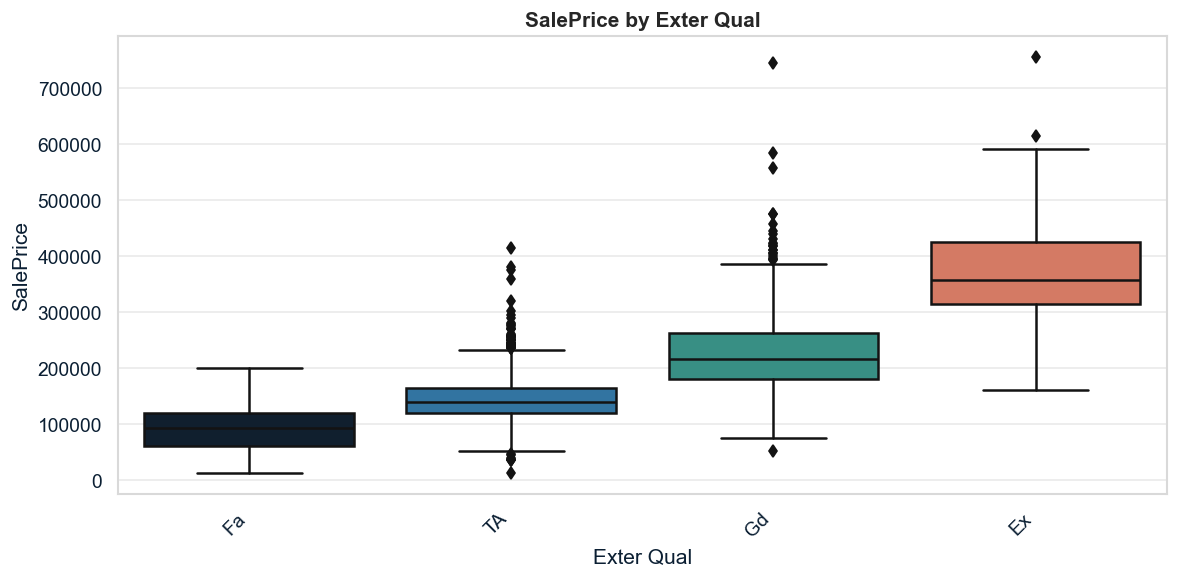

,count,mean,median,min,max
Exter Qual,,,,,
Ex,82,366703.451220,357950.0,160000,755000
Gd,773,227855.197930,216500.0,52000,745000
TA,1461,143564.074606,139500.0,12789,415000
Fa,28,94565.392857,93775.0,13100,200000


In [106]:
analyze_categorical_feature(train_data, "Exter Qual")

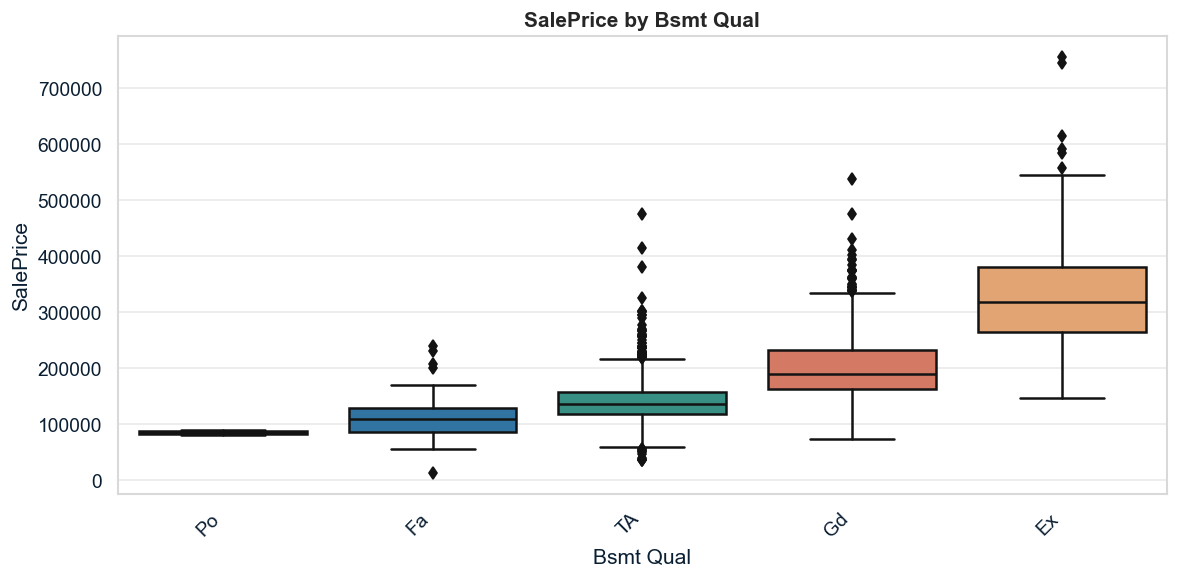

,count,mean,median,min,max
Bsmt Qual,,,,,
Ex,187,327948.775401,318061.0,147000,755000
Gd,970,200966.952577,190000.0,73000,538000
TA,1057,140369.694418,135500.0,34900,475000
Fa,67,111914.626866,109500.0,12789,240000
Po,2,84950.000000,84950.0,80900,89000


In [107]:
analyze_categorical_feature(train_data, "Bsmt Qual")

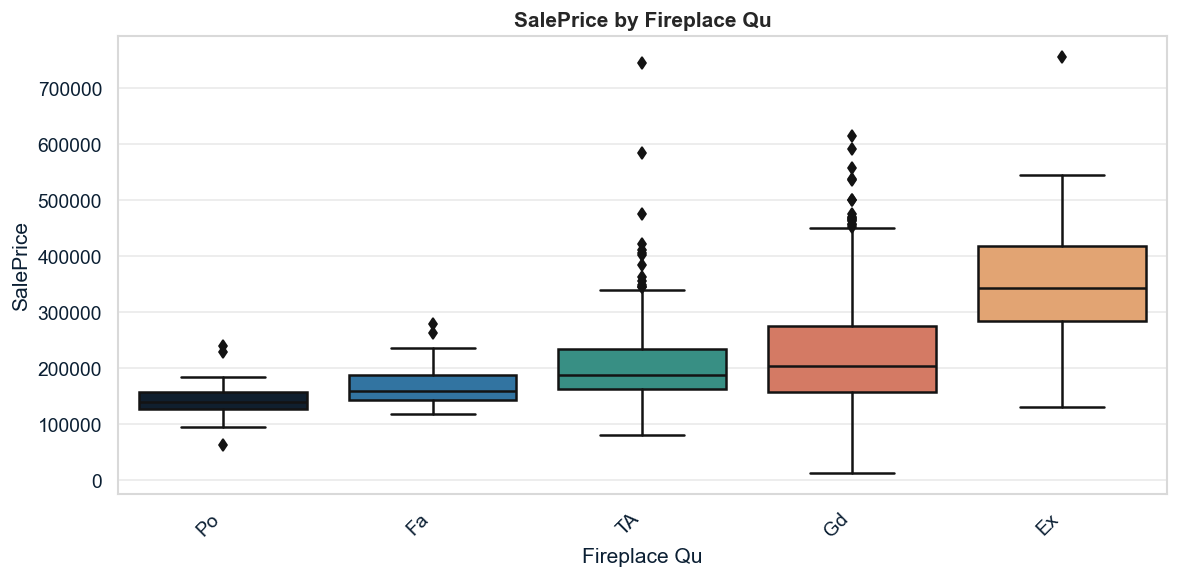

,count,mean,median,min,max
Fireplace Qu,,,,,
Ex,35,353428.914286,342000.0,130500,755000
Gd,580,224819.581034,203832.5,12789,615000
TA,483,202854.910973,188000.0,80000,745000
Fa,64,168655.390625,158250.0,117000,279000
Po,38,142832.447368,140000.0,62383,240050


In [108]:
analyze_categorical_feature(train_data, "Fireplace Qu")

Quality-related categorical features show a clear pattern: better quality levels are generally associated with higher sale prices.

This relationship is especially visible in **Kitchen Qual**, **Exter Qual** and **Bsmt Qual**, where houses classified as excellent or good tend to have substantially higher median prices than houses classified as typical or fair.

This suggests that qualitative property characteristics carry important predictive information and should be carefully encoded during modeling.

### 6.3 Garage, Sale Condition and House Style

Other categorical features also provide useful information about the property structure and transaction context.

In this step, I analyzed **Garage Type**, **Sale Condition** and **House Style** to understand how these categories relate to sale prices.

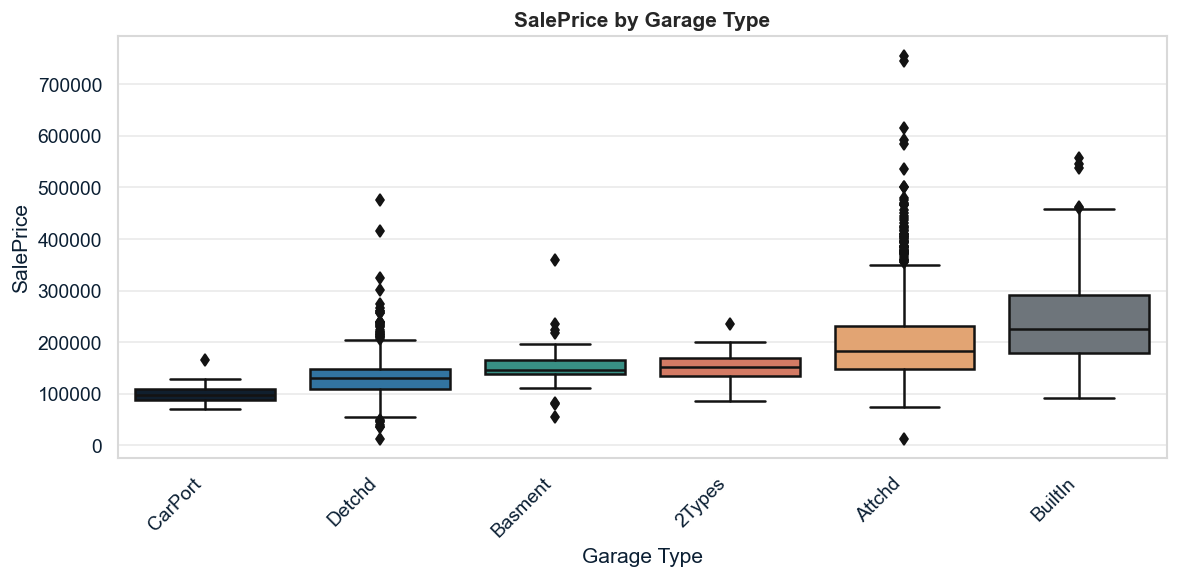

,count,mean,median,min,max
Garage Type,,,,,
BuiltIn,138,246470.971014,225000.0,91000,556581
Attchd,1397,200163.161059,182000.0,13100,755000
2Types,18,153088.888889,151200.0,87000,235000
Basment,30,155234.766667,146750.0,55993,359100
Detchd,631,132925.828843,129900.0,12789,475000
CarPort,10,103979.100000,98670.5,71000,164900


In [109]:
analyze_categorical_feature(train_data, "Garage Type")

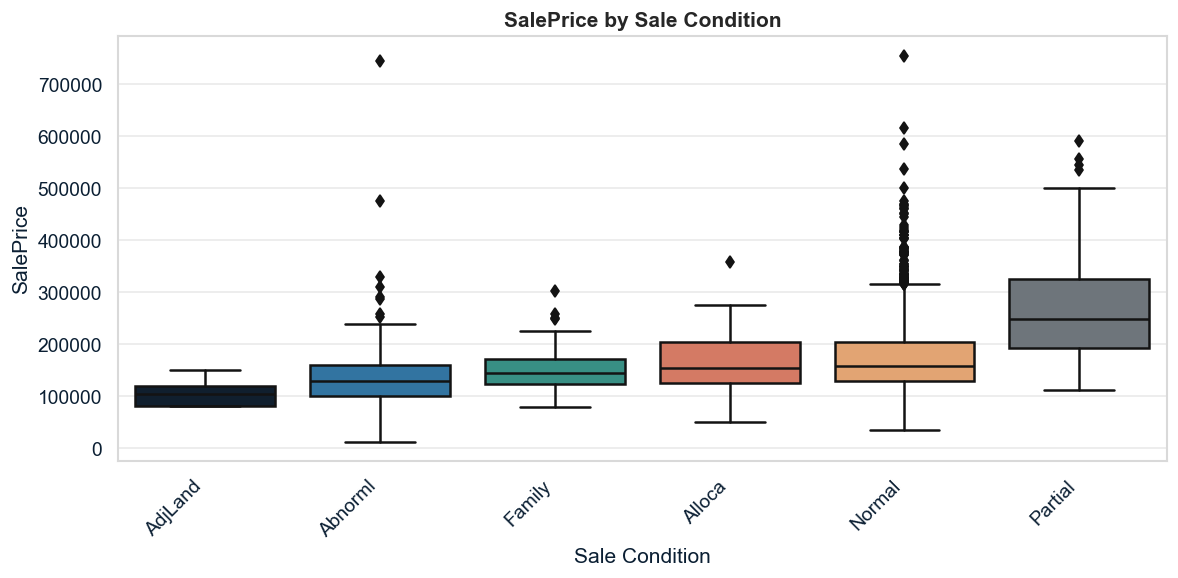

,count,mean,median,min,max
Sale Condition,,,,,
Partial,177,267603.096045,248328.0,113000,591587
Normal,1942,174544.577755,158000.0,35000,755000
Alloca,18,171711.888889,153770.5,50138,359100
Family,41,152062.804878,144800.0,79275,301600
Abnorml,158,139819.544304,129450.0,12789,745000
AdjLand,8,106062.500000,104500.0,81000,150000


In [110]:
analyze_categorical_feature(train_data, "Sale Condition")

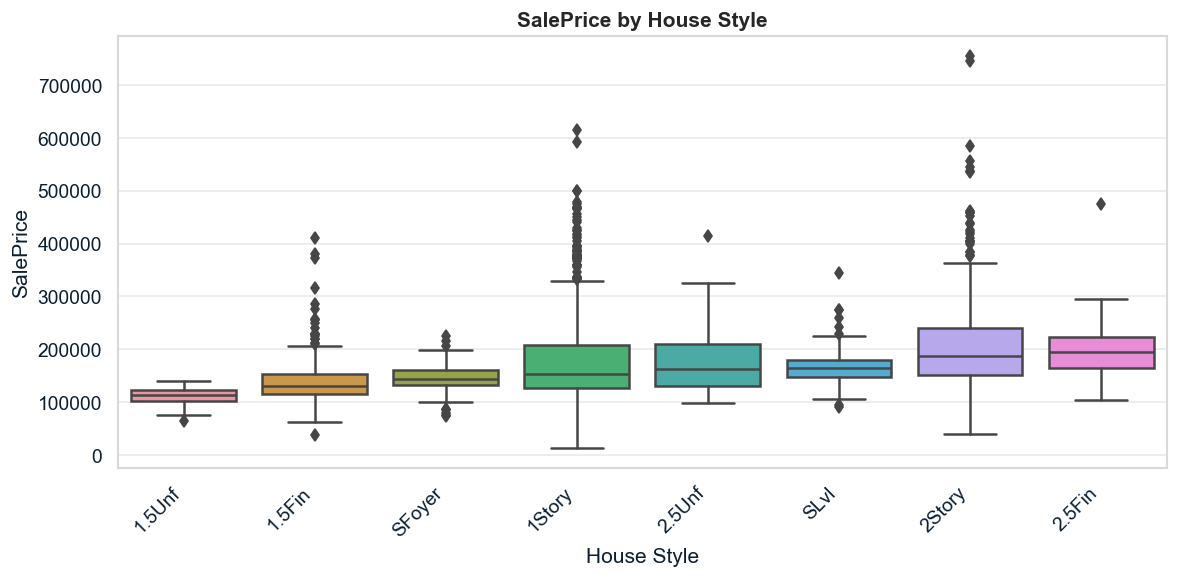

,count,mean,median,min,max
House Style,,,,,
2.5Fin,8,220000.000000,194000.0,104000,475000
2Story,694,203835.634006,187000.0,40000,755000
SLvl,104,167682.259615,165000.0,91000,345000
2.5Unf,21,182942.857143,161900.0,97500,415000
1Story,1191,175202.142737,153000.0,12789,615000
SFoyer,68,145172.235294,144000.0,73000,224500
1.5Fin,242,139632.008264,129950.0,37900,410000
1.5Unf,16,110350.000000,112750.0,64500,139400


In [111]:
analyze_categorical_feature(train_data, "House Style")

Garage type appears to influence house prices. Properties with built-in or attached garages tend to have higher sale prices than properties with detached garages or carports.

Sale condition also shows some price differences, although this feature may reflect specific transaction situations rather than only property quality.

House style has some relationship with price, but the pattern is less direct than quality-related variables. This suggests that house style may be useful, but probably not as strong as location, size or quality features.

### 6.4 Categorical Features Insights

The categorical analysis showed that qualitative and location-related variables are highly relevant for house price prediction.

**Neighborhood** appears to have a strong relationship with **SalePrice**, confirming that location is one of the most important drivers of property value.

Quality-related features such as **Kitchen Qual**, **Exter Qual**, **Bsmt Qual** and **Fireplace Qu** also showed clear price differences across categories. In general, houses with better quality ratings tend to have higher median sale prices.

Garage-related variables, especially **Garage Type**, also seem to influence house prices. Properties with attached or built-in garages are usually associated with higher prices than properties with detached garages or carports.

Some categorical variables contain missing values that likely represent the absence of a specific property feature, such as no garage, no basement or no fireplace. These missing values should be treated carefully instead of being removed automatically.

Overall, these findings suggest that categorical features will be important during preprocessing and modeling. Encoding strategies will be required before training machine learning models, and special attention should be given to high-impact variables such as **Neighborhood**, quality-related features and garage-related features.

## 7. Missing Values Analysis

In this section, I will analyze the missing values in the training data.

Missing values can have different meanings depending on the feature. In the Ames Housing dataset, some missing values do not necessarily represent missing information. In many cases, they indicate that the property does not have a specific feature, such as a garage, basement, fireplace, alley access or pool.

The goal of this section is to understand where missing values appear, separate real missing information from meaningful absence, and define a treatment strategy for the preprocessing step.

In [112]:
missing_values = train_data.isna().sum()
missing_values = missing_values[missing_values > 0]
missing_values = missing_values.sort_values(ascending=False)
missing_values

Pool QC           2332
Misc Feature      2250
Alley             2182
Fence             1874
Mas Vnr Type      1426
Fireplace Qu      1144
Lot Frontage       393
Garage Yr Blt      122
Garage Cond        122
Garage Qual        122
Garage Finish      122
Garage Type        120
Bsmt Exposure       63
BsmtFin Type 2      62
Bsmt Qual           61
BsmtFin Type 1      61
Bsmt Cond           61
Mas Vnr Area        19
BsmtFin SF 1         1
Bsmt Half Bath       1
Garage Cars          1
Garage Area          1
Total Bsmt SF        1
Bsmt Unf SF          1
BsmtFin SF 2         1
Bsmt Full Bath       1
dtype: int64

In [113]:
missing_summary = pd.DataFrame({
    'Missing Count': train_data.isna().sum(),
    'Missing Percentage': train_data.isna().mean() * 100,
    'Data Type': train_data.dtypes,
    'Unique Values': train_data.nunique(dropna=False)
})

missing_summary = missing_summary[missing_summary['Missing Count'] > 0]
missing_summary = missing_summary.sort_values(by='Missing Percentage', ascending=False)
missing_summary

,Missing Count,Missing Percentage,Data Type,Unique Values
Pool QC,2332,99.488055,object,5
Misc Feature,2250,95.989761,object,5
Alley,2182,93.088737,object,3
Fence,1874,79.948805,object,5
Mas Vnr Type,1426,60.836177,object,5
Fireplace Qu,1144,48.805461,object,6
Lot Frontage,393,16.766212,float64,121
Garage Yr Blt,122,5.204778,float64,103
Garage Cond,122,5.204778,object,6
Garage Qual,122,5.204778,object,6


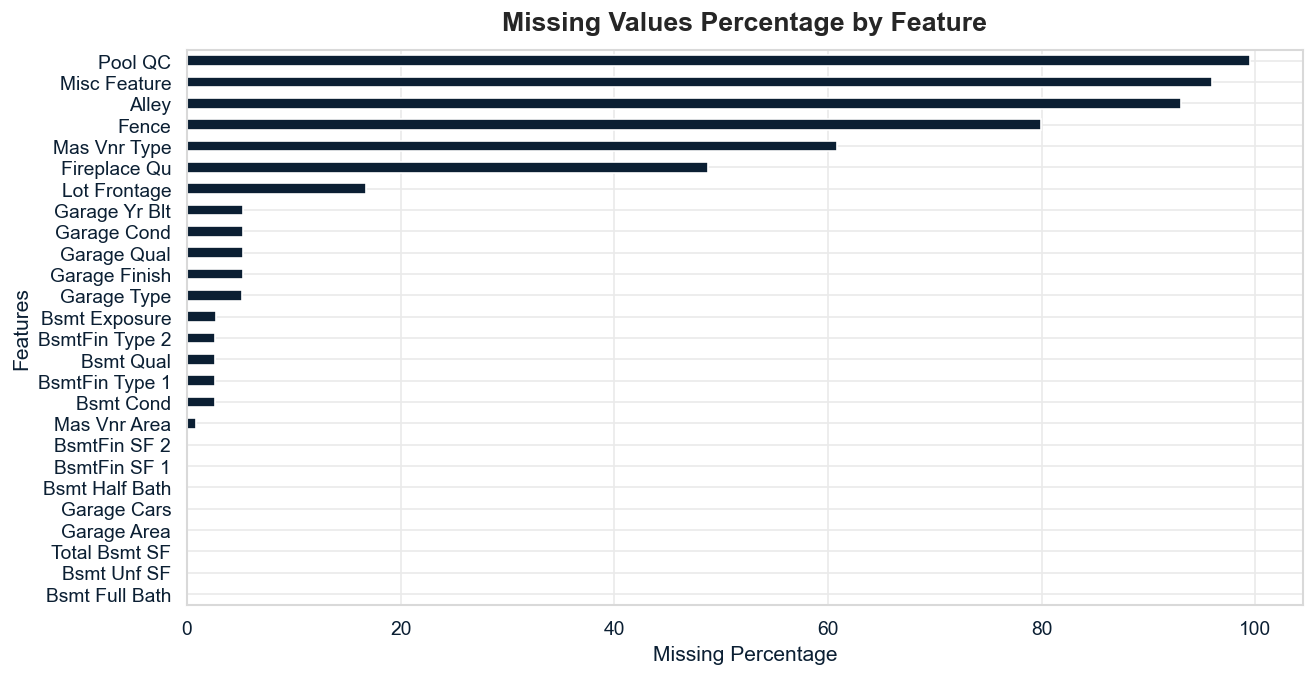

In [114]:
plt.figure(figsize=(12,6))
missing_summary['Missing Percentage'].sort_values().plot(kind='barh')
plt.title('Missing Values Percentage by Feature', fontsize=16, fontweight="bold", pad=12)
plt.xlabel('Missing Percentage')
plt.ylabel('Features')
plt.show()

In [115]:
categorical_columns = train_data.select_dtypes(include='object').columns
numerical_columns = train_data.select_dtypes(include=['int64', 'float64']).columns

categorical_missing = train_data[categorical_columns].isna().sum()
categorical_missing = categorical_missing[categorical_missing > 0].sort_values(ascending=False)

numerical_missing = train_data[numerical_columns].isna().sum()
numerical_missing = numerical_missing[numerical_missing > 0].sort_values(ascending=False)

print(f'Categorical features with missing values: {categorical_missing.shape[0]}')
print(f'Numerical features with missing values: {numerical_missing.shape[0]}')

Categorical features with missing values: 15
Numerical features with missing values: 11


In [116]:
categorical_missing

Pool QC           2332
Misc Feature      2250
Alley             2182
Fence             1874
Mas Vnr Type      1426
Fireplace Qu      1144
Garage Finish      122
Garage Qual        122
Garage Cond        122
Garage Type        120
Bsmt Exposure       63
BsmtFin Type 2      62
Bsmt Qual           61
Bsmt Cond           61
BsmtFin Type 1      61
dtype: int64

In [117]:
numerical_missing

Lot Frontage      393
Garage Yr Blt     122
Mas Vnr Area       19
BsmtFin SF 1        1
BsmtFin SF 2        1
Bsmt Unf SF         1
Total Bsmt SF       1
Bsmt Full Bath      1
Bsmt Half Bath      1
Garage Cars         1
Garage Area         1
dtype: int64

In [118]:
none_features = [
    "Pool QC",
    "Misc Feature",
    "Alley",
    "Fence",
    "Fireplace Qu",
    "Garage Type",
    "Garage Finish",
    "Garage Qual",
    "Garage Cond",
    "Bsmt Qual",
    "Bsmt Cond",
    "Bsmt Exposure",
    "BsmtFin Type 1",
    "BsmtFin Type 2",
    "Mas Vnr Type"
]

none_features_summary = missing_summary.loc[missing_summary.index.intersection(none_features)]
none_features_summary

,Missing Count,Missing Percentage,Data Type,Unique Values
Pool QC,2332,99.488055,object,5
Misc Feature,2250,95.989761,object,5
Alley,2182,93.088737,object,3
Fence,1874,79.948805,object,5
Mas Vnr Type,1426,60.836177,object,5
Fireplace Qu,1144,48.805461,object,6
Garage Cond,122,5.204778,object,6
Garage Qual,122,5.204778,object,6
Garage Finish,122,5.204778,object,4
Garage Type,120,5.119454,object,7


In [119]:
numeric_missing_features = numerical_missing.index.tolist()
numeric_missing_features

['Lot Frontage',
 'Garage Yr Blt',
 'Mas Vnr Area',
 'BsmtFin SF 1',
 'BsmtFin SF 2',
 'Bsmt Unf SF',
 'Total Bsmt SF',
 'Bsmt Full Bath',
 'Bsmt Half Bath',
 'Garage Cars',
 'Garage Area']

In [120]:
garage_columns = [
    "Garage Type",
    "Garage Yr Blt",
    "Garage Finish",
    "Garage Cars",
    "Garage Area",
    "Garage Qual",
    "Garage Cond"
]

train_data[garage_columns].isna().sum().sort_values(ascending=False)

Garage Yr Blt    122
Garage Finish    122
Garage Qual      122
Garage Cond      122
Garage Type      120
Garage Cars        1
Garage Area        1
dtype: int64

In [121]:
basement_columns = [
    "Bsmt Qual",
    "Bsmt Cond",
    "Bsmt Exposure",
    "BsmtFin Type 1",
    "BsmtFin SF 1",
    "BsmtFin Type 2",
    "BsmtFin SF 2",
    "Bsmt Unf SF",
    "Total Bsmt SF",
    "Bsmt Full Bath",
    "Bsmt Half Bath"
]

train_data[basement_columns].isna().sum().sort_values(ascending=False)

Bsmt Exposure     63
BsmtFin Type 2    62
Bsmt Qual         61
Bsmt Cond         61
BsmtFin Type 1    61
BsmtFin SF 1       1
BsmtFin SF 2       1
Bsmt Unf SF        1
Total Bsmt SF      1
Bsmt Full Bath     1
Bsmt Half Bath     1
dtype: int64

### Missing Values Insights

Several features contain missing values, but many of them seem to have a meaningful interpretation rather than being simple data quality problems.

Features such as Pool QC, Misc Feature, Alley, Fence and Fireplace Qu have a high percentage of missing values. In this dataset, this likely means that many houses do not have a pool, miscellaneous feature, alley access, fence or fireplace.

Garage-related variables also show missing values across multiple columns, such as Garage Type, Garage Finish, Garage Qual and Garage Cond. This suggests that these missing values are probably related to houses without a garage.

A similar pattern appears in basement-related variables. Missing values in features such as Bsmt Qual, Bsmt Cond, Bsmt Exposure and BsmtFin Type may indicate that the property does not have a basement.

Some numerical variables require more careful treatment. Lot Frontage, for example, seems to represent a missing measurement rather than the absence of a property feature. This variable will likely need an imputation strategy during preprocessing.

At this stage, I will not apply any missing value treatment yet. The goal here is only to understand the meaning of missing values and define a clear strategy for the data cleaning and preprocessing step.

## 8. Outliers Analysis

In this section, I will analyze potential outliers in important numerical features.

Outliers can strongly influence regression models, especially linear models. However, not every outlier should be removed automatically. In real estate data, extreme values may represent valid properties, such as very large houses, high-value homes or unusual lot sizes.

At this stage, the goal is only to identify and understand potential outliers. Any removal or treatment decision will be made later during the data cleaning and preprocessing step.

In [122]:
outlier_features = [
    "SalePrice",
    "Gr Liv Area",
    "Lot Area",
    "Total Bsmt SF",
    "Garage Area",
    "1st Flr SF"
]

outlier_features

['SalePrice',
 'Gr Liv Area',
 'Lot Area',
 'Total Bsmt SF',
 'Garage Area',
 '1st Flr SF']

In [123]:
outlier_summary_list = []

for feature in outlier_features:
    
    q1, q3, iqr, lower_limit, upper_limit, lower_outliers, upper_outliers, total_outliers = calculate_iqr_outliers(
        train_data,
        feature
    )
    
    outlier_summary_list.append({
        "Feature": feature,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Limit": lower_limit,
        "Upper Limit": upper_limit,
        "Lower Outliers": lower_outliers,
        "Upper Outliers": upper_outliers,
        "Total Outliers": total_outliers
    })

outlier_summary = pd.DataFrame(outlier_summary_list)
outlier_summary = outlier_summary.sort_values(by="Total Outliers", ascending=False)

outlier_summary

,Feature,Q1,Q3,IQR,Lower Limit,Upper Limit,Lower Outliers,Upper Outliers,Total Outliers
2,Lot Area,7466.50,11484.25,4017.75,1439.875,17510.875,1,112,113
0,SalePrice,129000.00,210000.00,81000.00,7500.000,331500.000,0,107,107
3,Total Bsmt SF,784.00,1288.00,504.00,28.000,2044.000,60,34,94
1,Gr Liv Area,1121.75,1734.00,612.25,203.375,2652.375,0,59,59
5,1st Flr SF,879.75,1378.00,498.25,132.375,2125.375,0,32,32
4,Garage Area,319.00,576.00,257.00,-66.500,961.500,0,30,30


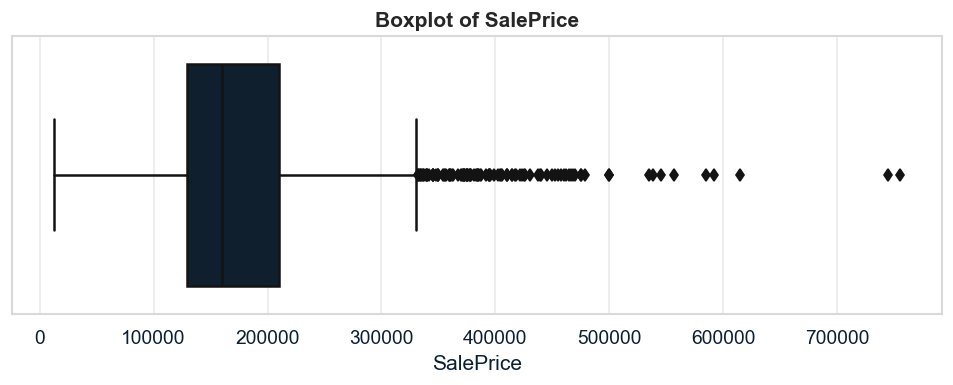

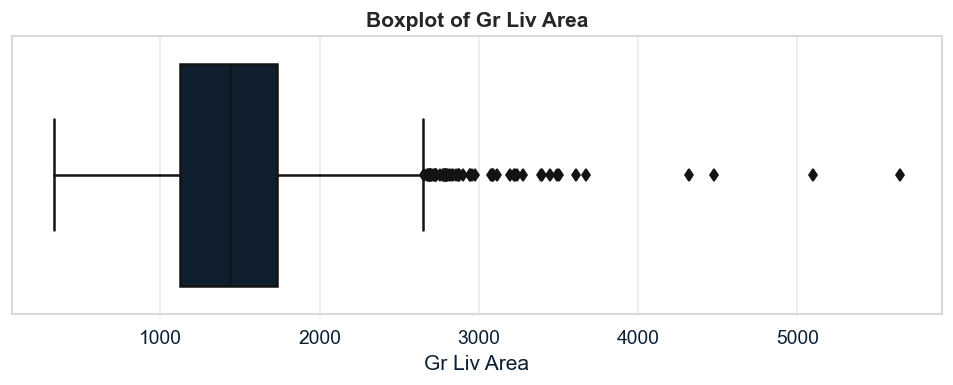

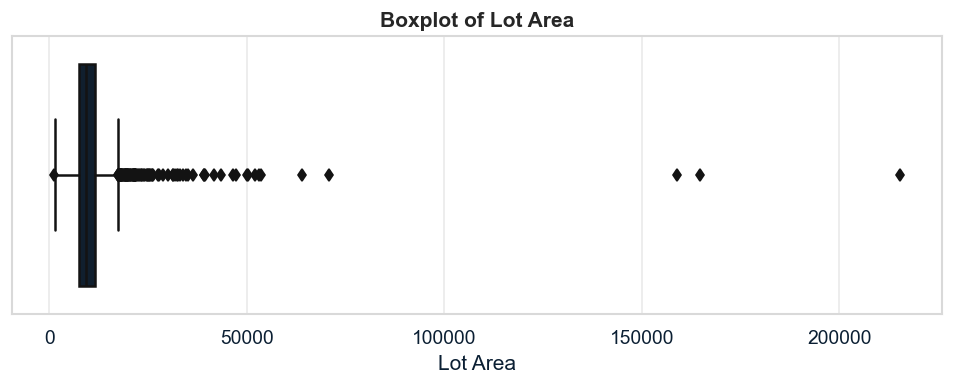

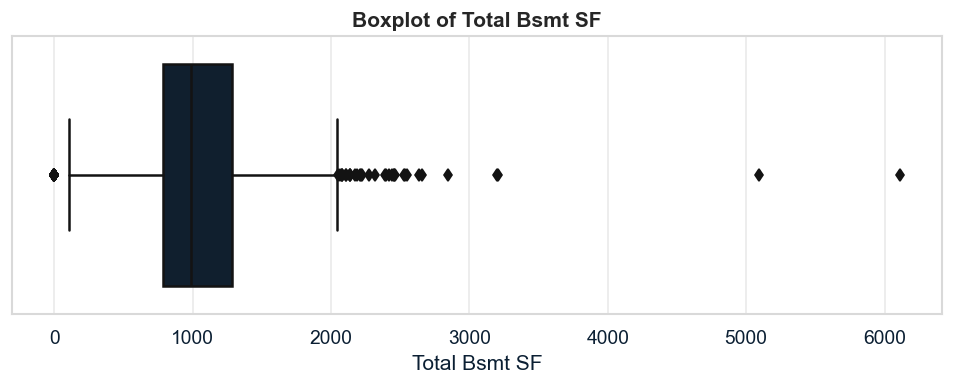

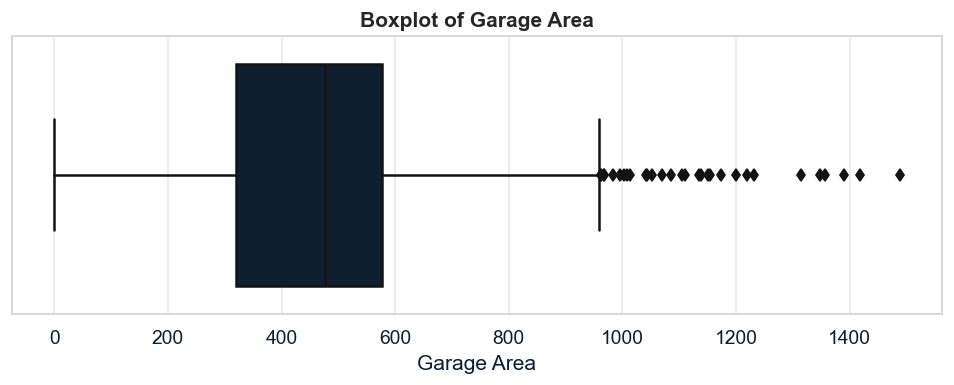

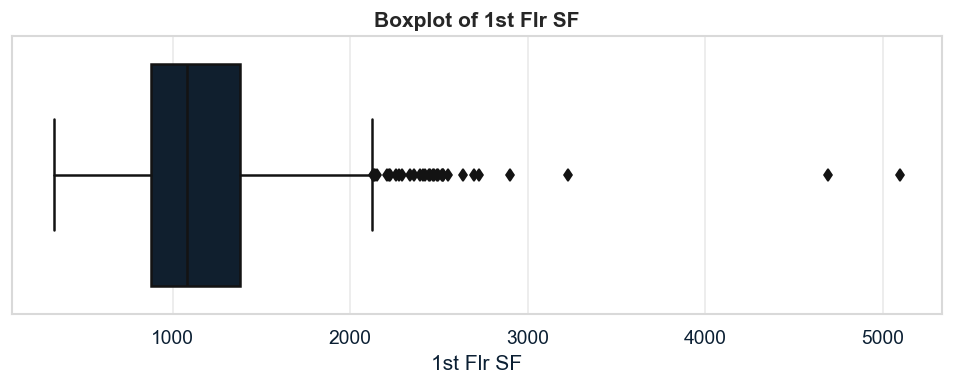

In [124]:
for feature in outlier_features:

    plt.figure(figsize=(10, 3))
    sns.boxplot(x=train_data[feature])
    plt.title(f"Boxplot of {feature}")
    plt.xlabel(feature)
    plt.show()

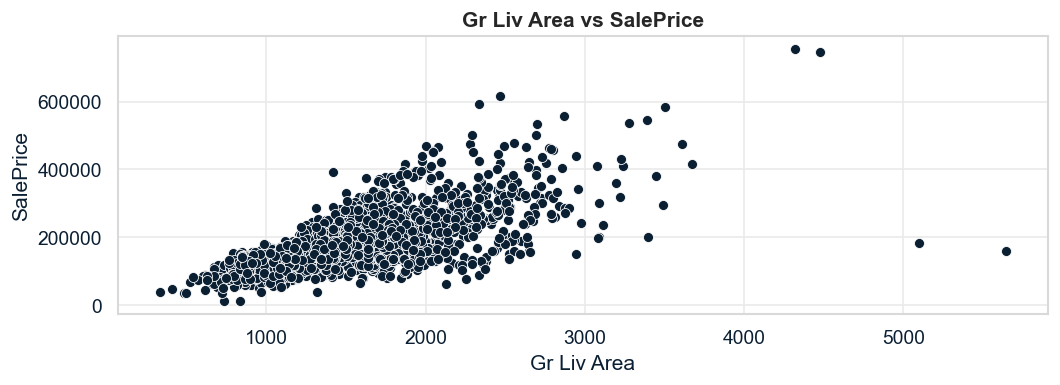

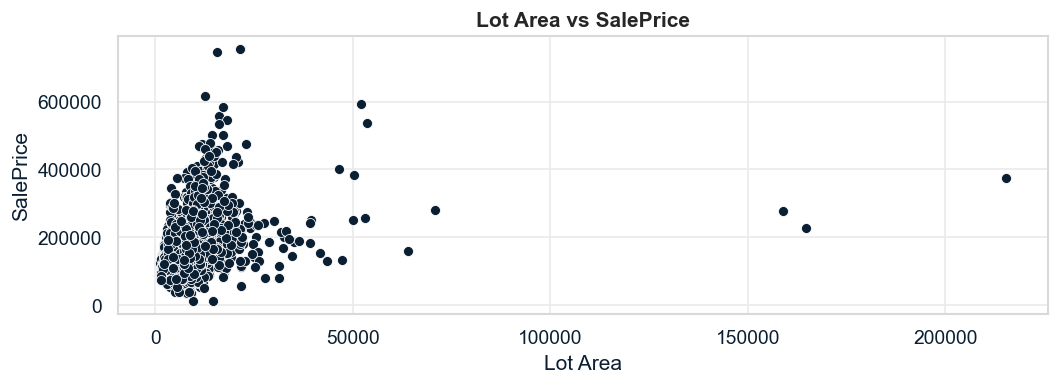

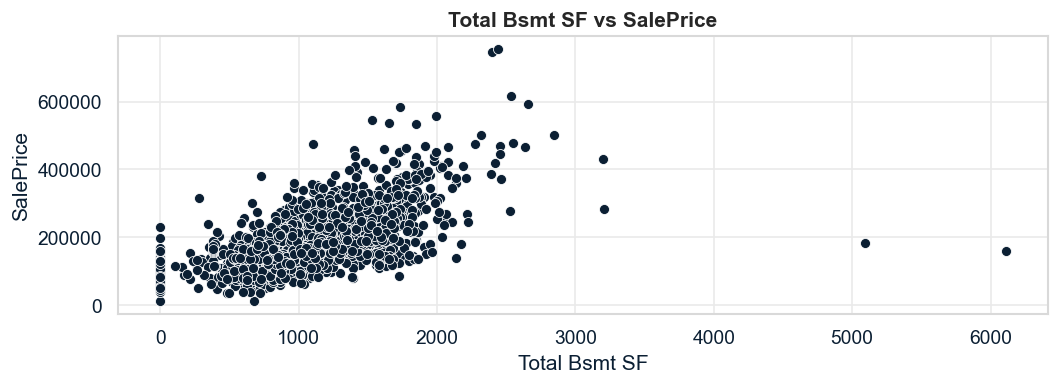

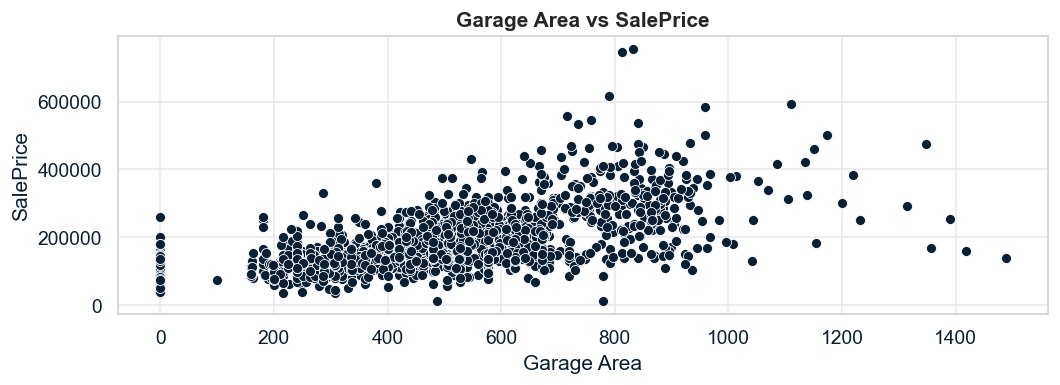

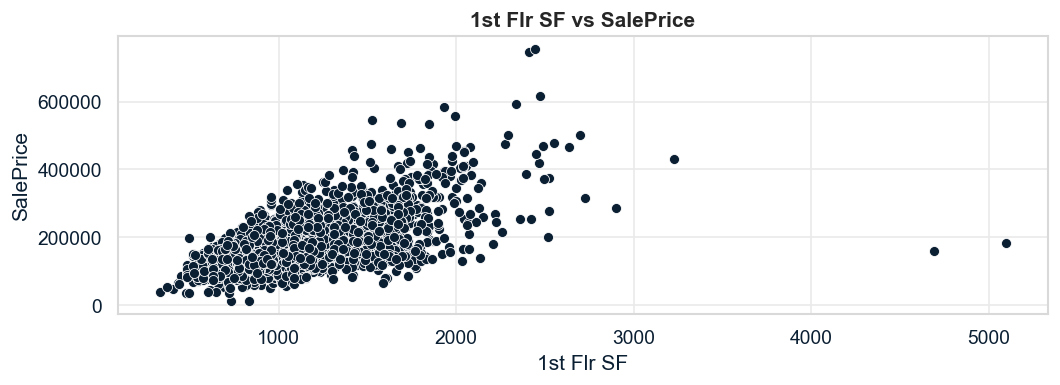

In [125]:
scatter_features = [
    "Gr Liv Area",
    "Lot Area",
    "Total Bsmt SF",
    "Garage Area",
    "1st Flr SF"
]

for feature in scatter_features:
    
    plt.figure(figsize=(10, 3))
    sns.scatterplot(
        data=train_data,
        x=feature,
        y="SalePrice"
    )
    plt.title(f"{feature} vs SalePrice")
    plt.xlabel(feature)
    plt.ylabel("SalePrice")
    plt.show()

In [126]:
large_living_area = train_data[train_data["Gr Liv Area"] > 4000]

large_living_area[
    [
        "Order",
        "PID",
        "Gr Liv Area",
        "SalePrice",
        "Overall Qual",
        "Neighborhood"
    ]
].sort_values(by="Gr Liv Area", ascending=False)

,Order,PID,Gr Liv Area,SalePrice,Overall Qual,Neighborhood
1498,1499,908154235,5642,160000,10,Edwards
2180,2181,908154195,5095,183850,10,Edwards
1760,1761,528320050,4476,745000,10,NoRidge
1767,1768,528351010,4316,755000,10,NoRidge


In [127]:
largest_lots = train_data[
    [
        "Order",
        "PID",
        "Lot Area",
        "SalePrice",
        "Neighborhood",
        "Overall Qual"
    ]
].sort_values(by="Lot Area", ascending=False)

largest_lots.head(10)

,Order,PID,Lot Area,SalePrice,Neighborhood,Overall Qual
956,957,916176125,215245,375000,Timber,7
1570,1571,916125425,164660,228950,Timber,5
2115,2116,906426060,159000,277000,ClearCr,6
2766,2767,906475200,70761,280000,ClearCr,7
1498,1499,908154235,63887,160000,Edwards,10
15,16,527216070,53504,538000,StoneBr,8
1402,1403,905401060,53227,256000,ClearCr,4
1637,1638,527216080,51974,591587,StoneBr,9
2522,2523,533350050,50271,385000,Veenker,9
2893,2894,916325040,50102,250764,Timber,6


In [128]:
highest_prices = train_data[
    [
        "Order",
        "PID",
        "SalePrice",
        "Gr Liv Area",
        "Overall Qual",
        "Neighborhood",
        "Year Built"
    ]
].sort_values(by="SalePrice", ascending=False)

highest_prices.head(10)

,Order,PID,SalePrice,Gr Liv Area,Overall Qual,Neighborhood,Year Built
1767,1768,528351010,755000,4316,10,NoRidge,1994
1760,1761,528320050,745000,4476,10,NoRidge,1996
1063,1064,528164060,615000,2470,10,NridgHt,2003
1637,1638,527216080,591587,2338,9,StoneBr,2006
2450,2451,528360050,584500,3500,9,NoRidge,1993
2332,2333,527212030,556581,2868,9,StoneBr,2005
2330,2331,527210040,545224,3390,10,StoneBr,2006
15,16,527216070,538000,3279,8,StoneBr,2003
2334,2335,527214060,535000,2698,10,StoneBr,2006
1701,1702,528118050,500067,2290,10,NridgHt,2007


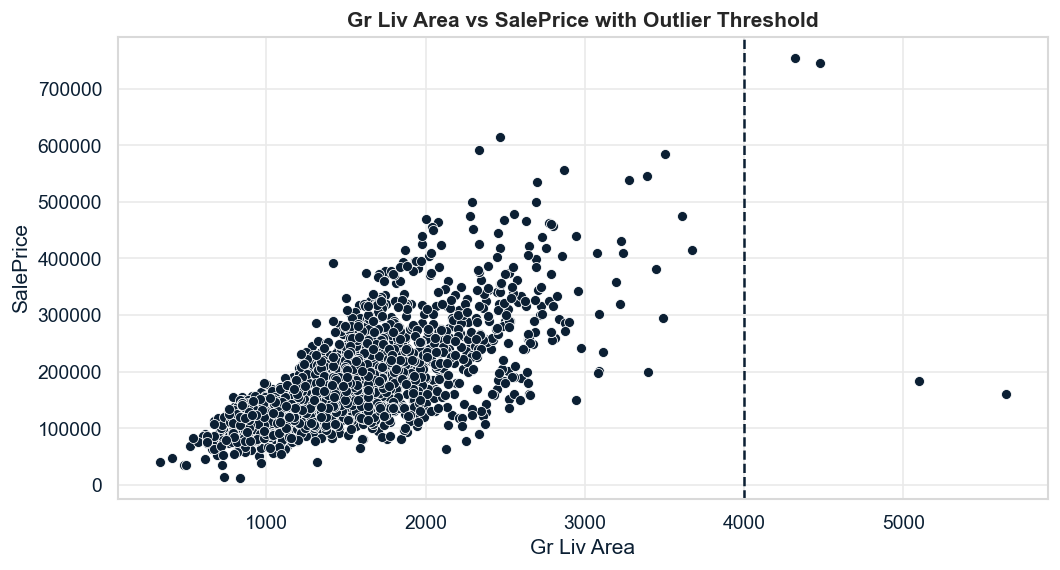

In [129]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=train_data,
    x="Gr Liv Area",
    y="SalePrice"
)
plt.axvline(
    x=4000,
    linestyle="--"
)
plt.title("Gr Liv Area vs SalePrice with Outlier Threshold")
plt.xlabel("Gr Liv Area")
plt.ylabel("SalePrice")
plt.show()

In [130]:
potential_gr_liv_area_outliers = train_data[
    train_data["Gr Liv Area"] > 4000
].index

print(f"Potential Gr Liv Area outliers: {len(potential_gr_liv_area_outliers)}")
potential_gr_liv_area_outliers

Potential Gr Liv Area outliers: 4


Index([1498, 1760, 1767, 2180], dtype='int64')

### Outliers Insights

Several numerical features contain potential outliers according to the IQR method. This is expected in real estate data, since some properties can be much larger, more expensive or structurally different from the majority of houses.

SalePrice contains high-price outliers, but these observations should not be removed automatically. Expensive houses may represent valid market cases and can provide important information for the model.

Lot Area also presents extreme values. However, large lots may be legitimate properties, so they need to be reviewed carefully instead of being treated as errors by default.

Gr Liv Area is the most important feature to inspect more closely. Some houses have very large above-ground living areas, but relatively low sale prices. These observations may have a strong influence on regression models and should be reviewed during the preprocessing step.

At this stage, no outliers were removed. The goal was only to identify and document potential extreme observations so that they can be handled properly later in the data cleaning and preprocessing stage.

## 9. Feature Engineering Ideas

Based on the exploratory data analysis, some new features may help improve model performance.

In this section, I will create a temporary copy of the training data and test a few feature engineering ideas. These features will not be permanently created in this notebook. They are only explored here as possible candidates for the preprocessing and modeling stage.

In [131]:
feature_data = train_data.copy()
feature_data.shape

(2344, 82)

In [132]:
feature_data["TotalSF"] = (
    feature_data["Total Bsmt SF"] +
    feature_data["1st Flr SF"] +
    feature_data["2nd Flr SF"]
)

feature_data[["Total Bsmt SF", "1st Flr SF", "2nd Flr SF", "TotalSF", "SalePrice"]].head()

,Total Bsmt SF,1st Flr SF,2nd Flr SF,TotalSF,SalePrice
381,1090.0,1370,0,2460.0,152000
834,1013.0,1160,966,3139.0,185000
1898,0.0,1224,0,1224.0,101800
678,0.0,1040,0,1040.0,90000
700,600.0,1101,600,2301.0,94550


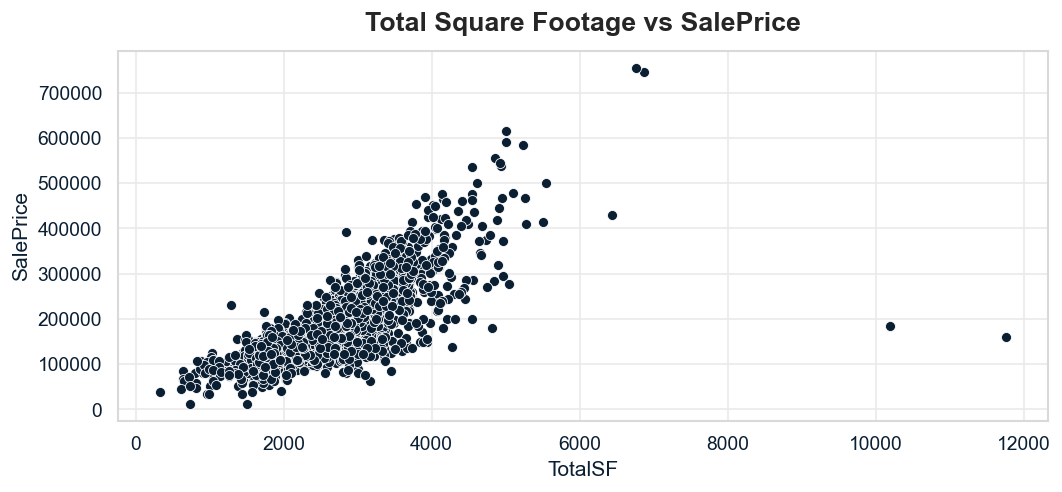

In [133]:
plt.figure(figsize=(10, 4))
sns.scatterplot(data=feature_data, x="TotalSF", y="SalePrice")
plt.title("Total Square Footage vs SalePrice", fontsize=16, fontweight="bold", pad=12)
plt.xlabel("TotalSF")
plt.ylabel("SalePrice")
plt.show()

In [134]:
feature_data["HouseAge"] = feature_data["Yr Sold"] - feature_data["Year Built"]
feature_data[["Yr Sold", "Year Built", "HouseAge", "SalePrice"]].head()

,Yr Sold,Year Built,HouseAge,SalePrice
381,2009,1976,33,152000
834,2009,1967,42,185000
1898,2007,1962,45,101800
678,2009,1949,60,90000
700,2009,1920,89,94550


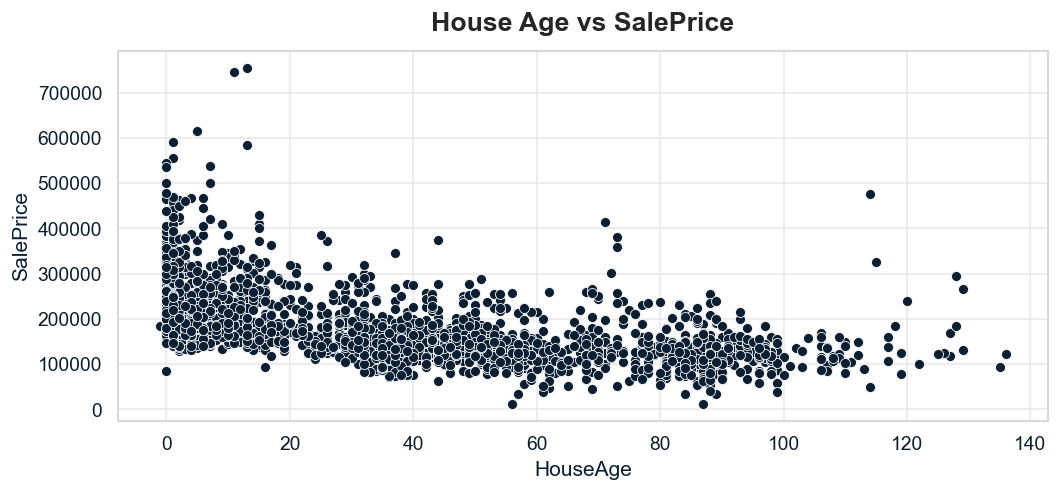

In [135]:
plt.figure(figsize=(10, 4))
sns.scatterplot(data=feature_data, x="HouseAge", y="SalePrice")
plt.title("House Age vs SalePrice", fontsize=16, fontweight="bold", pad=12)
plt.xlabel("HouseAge")
plt.ylabel("SalePrice")
plt.show()

In [136]:
feature_data["RemodAge"] = feature_data["Yr Sold"] - feature_data["Year Remod/Add"]
feature_data[["Yr Sold", "Year Remod/Add", "RemodAge", "SalePrice"]].head()

,Yr Sold,Year Remod/Add,RemodAge,SalePrice
381,2009,1976,33,152000
834,2009,1967,42,185000
1898,2007,1962,45,101800
678,2009,1950,59,90000
700,2009,1950,59,94550


In [137]:
feature_data["TotalBath"] = (
    feature_data["Full Bath"] +
    0.5 * feature_data["Half Bath"] +
    feature_data["Bsmt Full Bath"] +
    0.5 * feature_data["Bsmt Half Bath"]
)

feature_data[
    [
        "Full Bath",
        "Half Bath",
        "Bsmt Full Bath",
        "Bsmt Half Bath",
        "TotalBath",
        "SalePrice"
    ]
].head()

,Full Bath,Half Bath,Bsmt Full Bath,Bsmt Half Bath,TotalBath,SalePrice
381,2,0,0.0,0.0,2.0,152000
834,2,1,0.0,1.0,3.0,185000
1898,2,0,0.0,0.0,2.0,101800
678,2,0,0.0,0.0,2.0,90000
700,2,0,0.0,0.0,2.0,94550


In [138]:
feature_data["HasGarage"] = (feature_data["Garage Area"] > 0).astype(int)
feature_data["HasBasement"] = (feature_data["Total Bsmt SF"] > 0).astype(int)
feature_data["HasFireplace"] = (feature_data["Fireplaces"] > 0).astype(int)

feature_data[["Garage Area","HasGarage","Total Bsmt SF","HasBasement","Fireplaces","HasFireplace","SalePrice"]].head()

,Garage Area,HasGarage,Total Bsmt SF,HasBasement,Fireplaces,HasFireplace,SalePrice
381,479.0,1,1090.0,1,1,1,152000
834,538.0,1,1013.0,1,0,0,185000
1898,462.0,1,0.0,0,0,0,101800
678,420.0,1,0.0,0,0,0,90000
700,0.0,0,600.0,1,0,0,94550


In [139]:
engineered_features = ["TotalSF","HouseAge","RemodAge","TotalBath","HasGarage","HasBasement","HasFireplace","SalePrice"]

engineered_corr = feature_data[engineered_features].corr()["SalePrice"].sort_values(ascending=False)
engineered_corr

SalePrice       1.000000
TotalSF         0.777502
TotalBath       0.638812
HasFireplace    0.472267
HasGarage       0.220808
HasBasement     0.159864
RemodAge       -0.520096
HouseAge       -0.546208
Name: SalePrice, dtype: float64

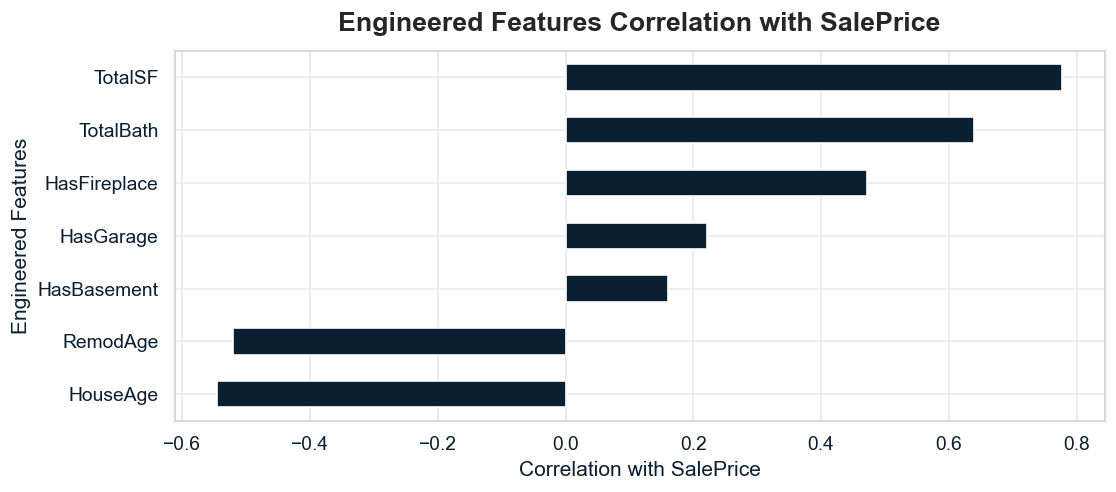

In [140]:
engineered_corr_without_target = engineered_corr.drop("SalePrice")
plt.figure(figsize=(10, 4))
engineered_corr_without_target.sort_values().plot(kind="barh")
plt.title("Engineered Features Correlation with SalePrice", fontsize=16, fontweight="bold", pad=12)
plt.xlabel("Correlation with SalePrice")
plt.ylabel("Engineered Features")
plt.show()

### Feature Engineering Insights

Some engineered features appear to be promising for the modeling stage.

TotalSF shows a strong relationship with SalePrice. This makes sense because it combines basement area, first floor area and second floor area into a single feature that represents the overall size of the property.

TotalBath also appears useful because it summarizes the bathroom capacity of the house instead of using each bathroom-related column separately.

HouseAge and RemodAge have negative correlations with SalePrice. This suggests that newer houses, or houses remodeled more recently, tend to be associated with higher sale prices.

Binary features such as HasGarage, HasBasement and HasFireplace may help the model capture whether the property has important structural characteristics.

These features will be considered later during preprocessing and modeling, but they are not permanently applied at this stage.

## 10. EDA Final Conclusions

This exploratory data analysis helped me understand the main patterns, risks and opportunities in the Ames Housing dataset before moving into preprocessing and modeling.

The target variable SalePrice showed a clear right-skewed distribution. Most houses are concentrated in lower and mid-price ranges, while a smaller group of expensive properties creates a long right tail. This is a common behavior in real estate data and suggests that a log transformation of the target may be useful during the modeling stage, especially for regression models that are sensitive to skewed distributions.

The numerical feature analysis showed that house prices are strongly related to quality, size and structural characteristics. Overall Qual was the numerical feature most correlated with SalePrice, which indicates that the overall material and finish quality of a house is one of the strongest price drivers in the dataset. Gr Liv Area also showed a strong positive relationship with SalePrice, confirming that larger above-ground living areas are generally associated with higher prices.

Garage-related variables, such as Garage Cars and Garage Area, also appeared among the most relevant numerical features. This suggests that garage capacity and garage size add meaningful value to a property. Other variables related to property size and structure, such as Total Bsmt SF, 1st Flr SF, Full Bath and Year Built, also showed important positive relationships with the target variable.

The categorical analysis also revealed relevant patterns. Neighborhood appears to be one of the most important categorical variables, which makes sense because location is a key factor in real estate pricing. Quality-related categorical features, such as Kitchen Qual, Exter Qual and Bsmt Qual, also showed clear differences in sale prices across their categories. This reinforces the idea that both location and perceived quality have a strong impact on house prices.

The missing values analysis showed that missing data in this dataset needs to be handled carefully. Many missing values do not necessarily represent data quality problems. In several columns, missing values likely indicate the absence of a property feature, such as no garage, no basement, no fireplace, no pool, no fence or no alley access. Because of this, these values should not be blindly removed or imputed without considering their meaning.

Some numerical variables with missing values require a different treatment strategy. For example, Lot Frontage appears to represent a truly missing measurement rather than the absence of a feature. This type of variable will likely require imputation during preprocessing, while absence-related variables may be better handled with specific labels or zero values depending on the feature.

The outlier analysis showed that several numerical variables contain potential extreme values, especially SalePrice, Gr Liv Area, Lot Area, Total Bsmt SF and Garage Area. However, these observations should not be removed automatically. In real estate data, extreme values can represent valid properties, such as luxury houses, very large lots or unusual structures. Some observations, especially houses with very large living areas but relatively low sale prices, should be reviewed carefully during the data cleaning step.

The analysis also suggested useful feature engineering ideas. Features such as TotalSF, HouseAge, RemodAge, TotalBath, HasGarage, HasBasement and HasFireplace may help the model capture important aspects of each property in a simpler and more meaningful way. TotalSF, in particular, appears promising because it combines basement area, first floor area and second floor area into a single measure of total property size.

Overall, the EDA showed that house prices in this dataset are mainly influenced by property quality, living area, garage characteristics, basement size, location and age-related features. It also highlighted important preprocessing decisions related to missing values, outliers, categorical encoding and target transformation.

The next notebook will focus on transforming these insights into a complete machine learning pipeline, including data cleaning, preprocessing, feature engineering, model training, model comparison, hyperparameter tuning and final evaluation.